# Analisis Segmentasi & Prediksi Garis Kemiskinan Kabupaten/Kota Indonesia (2011-2025)
### GEMASTIK 2026 Divisi Data Mining

### **Tim:** OTW Jakarta, Universitas Negeri Surabaya

Ferliyana Ronnan

Faris Riky Pratama

Lutfi Muhammad Irfansyach

---

## 1. Business Understanding

**Latar belakang.** Garis Kemiskinan (GK) adalah nilai rupiah per kapita per bulan yang menjadi ambang batas kemiskinan versi BPS. Nilai ini berbeda-beda antar 514 kabupaten/kota dan berubah setiap tahun mengikuti inflasi, biaya hidup, dan kondisi ekonomi lokal. Pemerintah pusat dan daerah butuh cara untuk (a) **mengelompokkan** wilayah berdasarkan pola pertumbuhan GK-nya bukan cuma nilainya saat ini supaya kebijakan bantuan sosial dan alokasi anggaran bisa lebih tepat sasaran, dan (b) **memprediksi** ke mana arah GK tiap kelompok wilayah dalam 1-3 tahun ke depan untuk perencanaan anggaran.

**Rumusan masalah data mining:**
1. Bagaimana mengelompokkan 514 kabupaten/kota berdasarkan karakteristik *pertumbuhan* GK 2011-2025 (bukan sekadar nilai absolut), agar wilayah dengan pola serupa bisa mendapat perlakuan kebijakan yang serupa?
2. Seberapa akurat GK masing-masing kelompok bisa diprediksi untuk 2026-2028, dan apakah prediksi ini benar-benar lebih baik daripada pendekatan naif?

**Target luaran:** (1) peta segmentasi wilayah dengan profil pertumbuhan yang jelas dan bisa diinterpretasi, (2) proyeksi GK 2026-2028 per segmen dengan interval ketidakpastian, (3) rekomendasi kebijakan yang dibedakan per segmen.

**Metodologi (CRISP-DM):** Business Understanding → Data Understanding → Data Preparation → Modeling (Clustering + Time Series Forecasting) → Evaluation → (Deployment: laporan & rekomendasi kebijakan).

## Cell 1
## Instalasi Library dan Setup Konfigurasi Global

### Library yang Digunakan

| Library | Fungsi dalam Notebook |
|---|---|
| `prophet` | Model time series utama untuk forecasting Garis Kemiskinan 2026-2028 per kluster |
| `scikit-learn` (`StandardScaler`, `MinMaxScaler`, `KMeans`, `PCA`, metrics) | Preprocessing fitur, algoritma clustering, reduksi dimensi untuk visualisasi, dan metrik evaluasi (silhouette, Davies-Bouldin, MAE, RMSE) |
| `scipy.stats` | Uji statistik (`linregress` untuk menghitung slope tren, `f_oneway` untuk ANOVA di bagian validasi eksternal) |
| `pandas` / `numpy` | Manipulasi data tabular dan komputasi numerik |
| `matplotlib` | Seluruh visualisasi (EDA, hasil clustering, forecasting) |

### Konfigurasi Global
- **`SEED = 42`** dipakai di semua operasi yang mengandung elemen acak (KMeans, train-test logic, dsb) supaya hasil notebook ini bisa direproduksi persis oleh siapa pun yang menjalankan ulang.
- **`PALETTE` & `COLORS`** set warna konsisten dipakai di seluruh grafik sepanjang notebook, supaya tiap kluster/kategori punya identitas warna yang sama dari EDA sampai forecasting.
- **`plt.rcParams.update(...)`** mengatur gaya visual default untuk semua plot sekaligus (DPI 120 untuk ketajaman, garis sumbu atas/kanan disembunyikan, grid tipis putus-putus) supaya tidak perlu mengulang setting yang sama di tiap cell visualisasi.
- Baris terakhir mencetak versi `scikit-learn` dan `prophet` praktik baik untuk reprodusibilitas, karena hasil model time series bisa sedikit berbeda antar versi library.

In [ ]:
!pip install prophet -q

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    mean_absolute_error, mean_squared_error
)
from prophet import Prophet

warnings.filterwarnings('ignore')

SEED = 42

PALETTE = {
    'blue': '#4C9BE8',
    'red': '#E74C3C',
    'green': '#2ECC71',
    'orange': '#F39C12',
    'purple': '#9B59B6',
    'gray': '#95A5A6',
}
COLORS = [PALETTE['blue'], PALETTE['red'], PALETTE['green'], PALETTE['orange']]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

print('Setup selesai!')
import sklearn, prophet
print(f'scikit-learn {sklearn.__version__} | prophet {prophet.__version__}')

Setup selesai!
scikit-learn 1.6.1 | prophet 1.3.0


## 2. Data Understanding & Data Preparation

**Sumber data:** 15 file CSV resmi BPS ("Garis Kemiskinan Menurut Kabupaten/Kota"), tahun 2011–2025. Tiap file berisi nilai GK (Rupiah/kapita/bulan) untuk provinsi (baris huruf kapital semua) dan kabupaten/kota di bawahnya.

**Langkah preparation:**
- Baca 15 file, gabungkan jadi satu tabel panjang (`wilayah`, `garis_kemiskinan`, `tahun`).
- Buang baris provinsi (agregat), sisakan level kabupaten/kota saja.
- Pivot ke bentuk lebar (`wilayah` × `tahun`), lalu isi nilai kosong dengan interpolasi linear antar-tahun + forward/backward fill untuk ujung deret yang masih kosong.

## Cell 2
## Load dan Preprocessing Data Garis Kemiskinan

### Sumber Data
15 file CSV resmi BPS ("Garis Kemiskinan Menurut Kabupaten/Kota"), satu file per tahun (2011-2025), masing-masing berisi nilai Garis Kemiskinan (Rupiah/kapita/bulan) untuk seluruh provinsi dan kabupaten/kota di Indonesia.

### Strategi Loading (Khusus Google Colab)
`DATA_DIR` diset tetap ke `/content` (lokasi kerja default Colab). Cell ini pertama-tama mencari file CSV yang sudah ada di situ lewat pola glob `Garis*Kemiskinan*Kabupaten*Kota*.csv` berguna kalau cell ini dijalankan ulang di sesi Colab yang sama tanpa perlu upload ulang. Kalau belum ada (`if not files_csv`), widget `files.upload()` otomatis muncul supaya pengguna bisa pilih 15 file CSV sekaligus (Ctrl+Click / Cmd+Click), lalu pencarian file diulang untuk menangkap file yang baru diupload.

### Langkah Parsing per File
1. **`skiprows=2`** dua baris pertama tiap file CSV BPS adalah judul dan header tahun, bukan data; baris ketiga dan seterusnya baru berisi pasangan `wilayah, nilai`.
2. Kolom tahun diambil dari nama file lewat regex `(\d{4})`, bukan dari isi file karena tiap file cuma punya satu kolom nilai tanpa label tahun eksplisit.
3. Baris kosong dan nilai `'-'` (notasi BPS untuk data tidak tersedia) dikonversi jadi `NaN` lewat `pd.to_numeric(errors='coerce')`.

### Memisahkan Provinsi vs Kabupaten/Kota
BPS menuliskan nama provinsi dalam huruf kapital semua (mis. `ACEH`), sedangkan kabupaten/kota pakai title case (mis. `Simeulue`). Baris `combined['wilayah'].str.upper() == combined['wilayah']` memanfaatkan pola ini: kalau nama wilayah sama persis dengan versi huruf besarnya, berarti itu baris agregat provinsi bukan level analisis yang dipakai di notebook ini, sehingga dibuang lewat `kabkota = combined[~combined['is_provinsi']]`.

### Reshape ke Wide Format & Imputasi
- `pivot_table` mengubah data dari format panjang (satu baris per wilayah-tahun) ke format lebar (satu baris per wilayah, satu kolom per tahun) bentuk yang dibutuhkan untuk analisis time series per wilayah di cell-cell berikutnya.
- `interpolate(axis=1, method='linear')` mengisi nilai kosong di tengah deret waktu dengan interpolasi linear antar titik yang ada di kiri-kanannya.
- `.ffill(axis=1).bfill(axis=1)` sebagai pengaman tambahan untuk nilai kosong yang berada di ujung deret (awal atau akhir tahun), di mana interpolasi linear tidak bisa bekerja karena tidak ada titik di salah satu sisi.

In [ ]:
import glob, re
from google.colab import files

DATA_DIR = '/content'
OUTPUT_DIR = os.path.join(DATA_DIR, 'output')

files_csv = sorted(glob.glob(os.path.join(DATA_DIR, 'Garis*Kemiskinan*Kabupaten*Kota*.csv')))

if not files_csv:
    print('Pilih semua 15 file CSV Garis Kemiskinan sekaligus (Ctrl+Click / Cmd+Click)')
    uploaded = files.upload()
    print(f'\nBerhasil diupload: {len(uploaded)} file')
    files_csv = sorted(glob.glob(os.path.join(DATA_DIR, 'Garis*Kemiskinan*Kabupaten*Kota*.csv')))

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'\nDitemukan {len(files_csv)} file CSV')

dfs = []
for f in files_csv:
    year = int(re.search(r'(\d{4})', os.path.basename(f)).group(1))
    df = pd.read_csv(f, skiprows=2, header=None,
                     names=['wilayah', 'garis_kemiskinan'],
                     encoding='utf-8-sig')
    df['tahun'] = year
    df = df.dropna(subset=['wilayah'])
    df = df[df['wilayah'].str.strip() != '']
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined['wilayah'] = combined['wilayah'].str.strip()
combined['garis_kemiskinan'] = combined['garis_kemiskinan'].replace('-', np.nan)
combined['garis_kemiskinan'] = pd.to_numeric(combined['garis_kemiskinan'], errors='coerce')

combined['is_provinsi'] = combined['wilayah'].str.upper() == combined['wilayah']
kabkota = combined[~combined['is_provinsi']].copy()

pivot = kabkota.pivot_table(index='wilayah', columns='tahun',
                             values='garis_kemiskinan', aggfunc='first')
pivot.columns = pivot.columns.astype(str)

wide = pivot.interpolate(axis=1, method='linear').ffill(axis=1).bfill(axis=1)
years = [int(c) for c in wide.columns]

wide.to_csv(os.path.join(OUTPUT_DIR, 'garis_kemiskinan_wide.csv'))
long = wide.reset_index().melt(id_vars='wilayah', var_name='tahun', value_name='garis_kemiskinan')
long['tahun'] = long['tahun'].astype(int)
long.to_csv(os.path.join(OUTPUT_DIR, 'garis_kemiskinan_long.csv'), index=False)

print(f'\nTotal kabupaten/kota : {wide.shape[0]}')
print(f'Tahun : {wide.columns[0]} - {wide.columns[-1]}')
print(f'Missing setelah imputasi : {wide.isnull().sum().sum()}')
print(f'\nSample data:')
wide.iloc[:5, :5]


Ditemukan 15 file CSV

Total kabupaten/kota : 514
Tahun : 2011 - 2025
Missing setelah imputasi : 0

Sample data:


tahun,2011,2012,2013,2014,2015
wilayah,,,,,
Aceh Barat,402636.0,407442.0,413061.0,417641.0,424227.0
Aceh Barat Daya,274089.0,276324.0,283117.0,288713.0,292323.0
Aceh Besar,351800.0,352112.0,352451.0,352751.0,366676.0
Aceh Jaya,291333.0,296921.0,303209.0,308891.0,316304.0
Aceh Selatan,278854.0,281158.0,283446.0,285301.0,288619.0


## Cell 3
## Exploratory Data Analysis (EDA)

### Tujuan
Memahami pola dan sebaran data Garis Kemiskinan sebelum masuk ke tahap feature engineering dan modeling termasuk mengecek apakah ada outlier, bagaimana distribusi nilainya berubah dari waktu ke waktu, dan wilayah mana yang paling ekstrem pertumbuhannya.

### Visualisasi yang Dihasilkan (grid 2×3)

| Posisi | Grafik | Insight yang Dicari |
|---|---|---|
| (0,0) | Tren nasional rata-rata GK 2011-2025 | Arah pergerakan GK secara keseluruhan (naik/turun/stagnan) |
| (0,1) | Histogram distribusi GK 2011 vs 2025 (overlay) | Apakah sebaran nilai antar wilayah melebar atau menyempit seiring waktu |
| (0,2) | Top 10 kenaikan GK 2011→2025 (`kenaikan_pct.nlargest(10)`) | Wilayah dengan lonjakan GK paling ekstrem |
| (1,0) | 10 wilayah dengan kenaikan paling lambat (`nsmallest(10)`) | Wilayah paling stabil / tertinggal pertumbuhan biaya hidupnya |
| (1,1) | Tren GK 10 kota besar Indonesia | Perbandingan pola antar kota metropolitan yang familiar |
| (1,2) | Boxplot sebaran GK per tahun | Perkembangan median, kuartil, dan outlier dari tahun ke tahun |

### Detail Teknis
- `kenaikan_pct = (wide['2025'] - wide['2011']) / wide['2011'] * 100` dihitung sekali di awal cell dan dipakai ulang untuk dua subplot (top 10 dan bottom 10), menghindari kalkulasi ganda.
- `mticker.FuncFormatter` dipakai berulang kali untuk memformat label sumbu-Y dari angka rupiah mentah (mis. `450000`) menjadi notasi ringkas (`Rp 450K`), supaya sumbu grafik tidak penuh angka nol.
- Untuk subplot kota besar, ada pengecekan `if kota in wide.index` bukan asumsi semua nama kota pasti cocok persis dengan penulisan di data BPS, jadi cell ini aman dijalankan meski ada nama yang sedikit berbeda.
- Boxplot pakai `patch_artist=True` supaya kotaknya bisa diberi warna custom (bukan hanya outline default matplotlib), dan `flierprops` mengatur tampilan titik outlier supaya tidak terlalu mendominasi visual.

Semua figure disimpan ke `OUTPUT_DIR` sebagai `eda_garis_kemiskinan.png` untuk dipakai ulang di laporan/proposal di luar notebook.

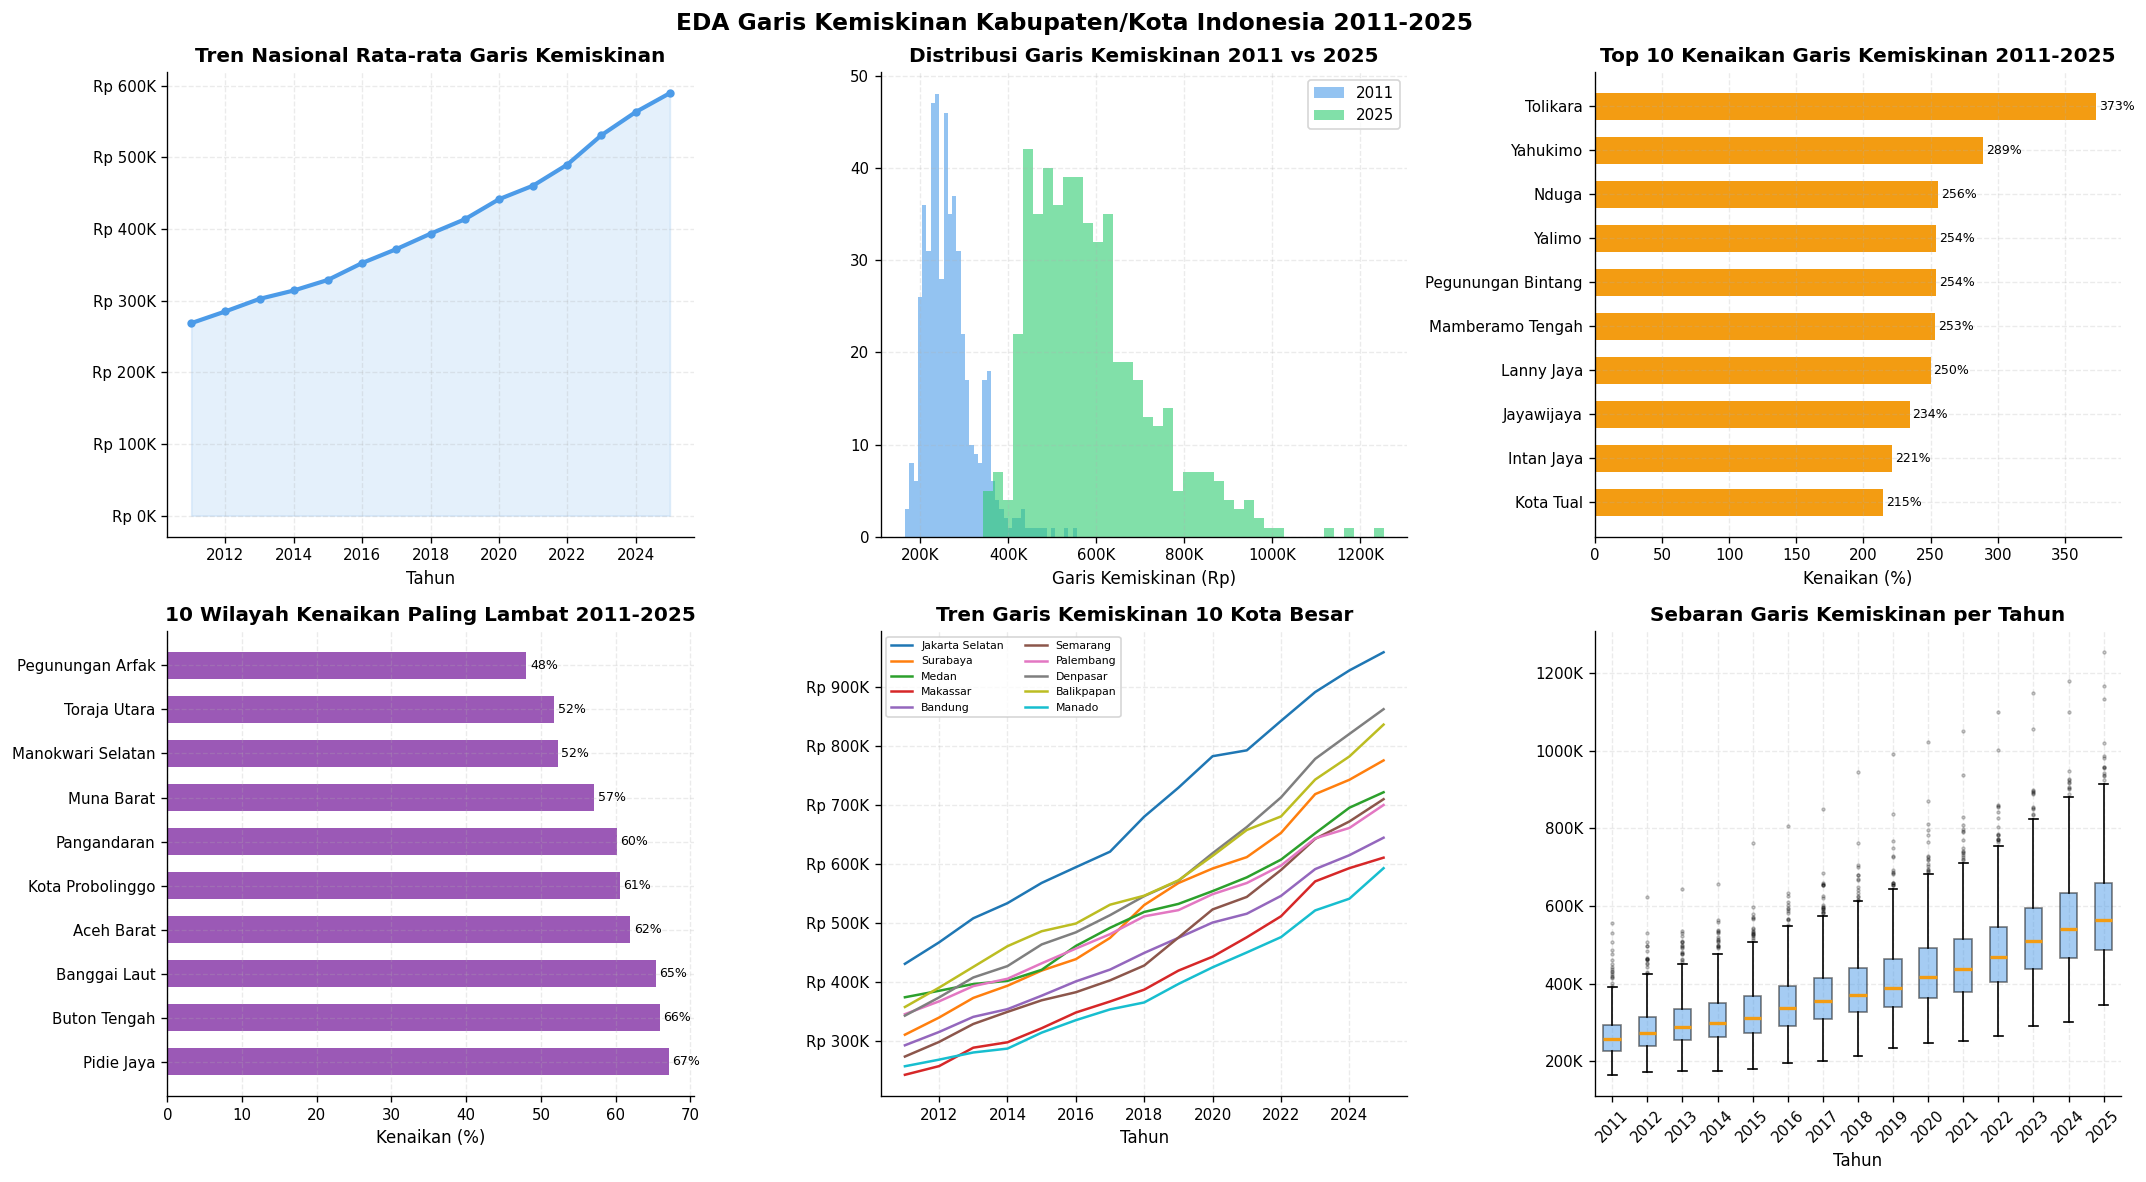

EDA selesai. Plot tersimpan ke output folder.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA Garis Kemiskinan Kabupaten/Kota Indonesia 2011-2025', fontsize=14, fontweight='bold')

kenaikan_pct = (wide['2025'] - wide['2011']) / wide['2011'] * 100

ax = axes[0, 0]
tren = wide.mean()
ax.plot(years, tren.values, color=PALETTE['blue'], linewidth=2.5, marker='o', markersize=4)
ax.fill_between(years, tren.values, alpha=0.15, color=PALETTE['blue'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e3:.0f}K'))
ax.set_title('Tren Nasional Rata-rata Garis Kemiskinan')
ax.set_xlabel('Tahun')

ax = axes[0, 1]
ax.hist(wide['2011'].dropna(), bins=40, alpha=0.6, color=PALETTE['blue'], label='2011')
ax.hist(wide['2025'].dropna(), bins=40, alpha=0.6, color=PALETTE['green'], label='2025')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(fontsize=9)
ax.set_title('Distribusi Garis Kemiskinan 2011 vs 2025')
ax.set_xlabel('Garis Kemiskinan (Rp)')

ax = axes[0, 2]
top10 = kenaikan_pct.nlargest(10)
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=PALETTE['orange'], height=0.6)
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=7.5)
ax.set_title('Top 10 Kenaikan Garis Kemiskinan 2011-2025')
ax.set_xlabel('Kenaikan (%)')

ax = axes[1, 0]
bot10 = kenaikan_pct.nsmallest(10)
bars2 = ax.barh(bot10.index[::-1], bot10.values[::-1], color=PALETTE['purple'], height=0.6)
for bar, val in zip(bars2, bot10.values[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=7.5)
ax.set_title('10 Wilayah Kenaikan Paling Lambat 2011-2025')
ax.set_xlabel('Kenaikan (%)')

ax = axes[1, 1]
kota_besar = ['Kota Jakarta Selatan','Kota Surabaya','Kota Medan','Kota Makassar','Kota Bandung','Kota Semarang','Kota Palembang','Kota Denpasar','Kota Balikpapan','Kota Manado']
cmap_lines = plt.cm.tab10(np.linspace(0, 1, 10))
for i, kota in enumerate(kota_besar):
    if kota in wide.index:
        vals = wide.loc[kota, [str(y) for y in years]].values.astype(float)
        ax.plot(years, vals, label=kota.replace('Kota ',''), linewidth=1.5, color=cmap_lines[i])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e3:.0f}K'))
ax.legend(fontsize=6.5, ncol=2)
ax.set_title('Tren Garis Kemiskinan 10 Kota Besar')
ax.set_xlabel('Tahun')

ax = axes[1, 2]
data_box = [wide[str(y)].dropna().values for y in years]
bp = ax.boxplot(data_box, labels=years, patch_artist=True,
                medianprops=dict(color=PALETTE['orange'], linewidth=2),
                flierprops=dict(marker='.', color=PALETTE['red'], alpha=0.3, markersize=3))
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE['blue']); patch.set_alpha(0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=45)
ax.set_title('Sebaran Garis Kemiskinan per Tahun')
ax.set_xlabel('Tahun')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_garis_kemiskinan.png'), bbox_inches='tight', dpi=120)
plt.show()
print('EDA selesai. Plot tersimpan ke output folder.')

**Insight EDA:**
- Tren nasional GK naik konsisten tiap tahun, tanpa penurunan konsisten dengan inflasi kumulatif 2011–2025.
- Distribusi 2025 bergeser ke kanan dan melebar dibanding 2011 → kesenjangan GK absolut antar wilayah makin lebar, bukan makin menyempit.
- Boxplot per tahun menunjukkan outlier di sisi atas (wilayah dengan GK jauh di atas median) konsisten muncul tiap tahun ini sinyal awal bahwa ada segmen wilayah "mahal" yang perlu ditangani terpisah dalam clustering, bukan diperlakukan sebagai gangguan/noise.
- Grafik top-10 vs bottom-10 kenaikan menunjukkan variasi laju pertumbuhan sangat besar antar wilayah inilah alasan clustering ini dibangun dari fitur **pertumbuhan** (CAGR, slope, akselerasi), bukan cuma dari nilai GK absolut.

## 3. Modeling: Feature Engineering, Clustering & Forecasting

Bagian ini membangun fitur pertumbuhan dari data GK, memilih algoritma & jumlah kluster yang paling didukung data, lalu memproyeksikan tiap kluster dengan Prophet yang parameternya sudah di-tuning.

## Cell 4
## Feature Engineering: Membangun Fitur Pertumbuhan

### Prinsip Utama
Alih-alih meng-cluster wilayah berdasarkan **nilai GK absolut** semata (yang cenderung hanya memisahkan "wilayah mahal" vs "wilayah murah"), cell ini membangun fitur yang menangkap **pola pertumbuhan** kecepatan, arah, dan volatilitas kenaikan GK sehingga clustering nantinya bisa membedakan wilayah berdasarkan *lintasan* (trajectory), bukan cuma posisi statis di satu titik waktu.

### Fitur yang Dibangun

| Fitur | Formula / Cara Hitung | Makna |
|---|---|---|
| `mean`, `median` | Rata-rata / median GK sepanjang 2011-2025 | Level GK jangka panjang |
| `std`, `cv` | Standar deviasi; `cv = std / mean` | Volatilitas absolut dan relatif (coefficient of variation menormalkan volatilitas terhadap level, supaya wilayah GK-tinggi tidak otomatis dianggap "lebih volatil" hanya karena skalanya besar) |
| `growth_total_pct` | `(GK_2025 - GK_2011) / GK_2011 * 100` | Kenaikan total selama 14 tahun |
| `cagr` | `((GK_2025 / GK_2011) ** (1/14) - 1) * 100` | Compound Annual Growth Rate laju pertumbuhan tahunan majemuk, lebih adil untuk perbandingan antar wilayah dibanding growth_total_pct karena memperhitungkan efek compounding |
| `slope`, `r2_linear` | `scipy.stats.linregress(tahun, nilai_GK)` per wilayah | Kemiringan tren linear GK sepanjang waktu (Rupiah/tahun), plus R² sebagai indikator seberapa linear tren tersebut |
| `slope_early`, `slope_late` | Regresi linear terpisah untuk 2011-2016 vs 2020-2025 | Kecepatan kenaikan di periode awal vs periode akhir |
| `acceleration` | `slope_late - slope_early` | Apakah laju kenaikan wilayah ini makin cepat (positif) atau melambat (negatif) fitur ini yang menangkap wilayah dengan pola "tadinya stabil, tiba-tiba melonjak" |
| `growth_2011_2015`, `growth_2015_2020`, `growth_2020_2025` | Kenaikan persentase per sub-periode 5 tahunan | Menangkap pola pertumbuhan di tiap fase, termasuk efek pasca-pandemi pada window terakhir |

### Detail Teknis
- Loop `for idx in wide.index` dipakai untuk `linregress` karena fungsi ini butuh dijalankan per baris (per wilayah) tidak ada versi vectorized bawaan di scipy untuk regresi linear per grup.
- `early_yrs` dan `late_yrs` sengaja dipisah 6 tahun di masing-masing ujung (2011-2016 dan 2020-2025) supaya regresi punya cukup titik data (n=6) untuk estimasi slope yang stabil, sambil tetap menyisakan jarak yang jelas antara periode awal dan akhir.

Fitur lengkap (bukan cuma yang dipakai untuk clustering) disimpan ke `features.csv` enam kolom yang benar-benar dipakai untuk clustering baru dipilih secara eksplisit di Cell 5 berikutnya.

In [ ]:
years_np = np.array(years)
feats = pd.DataFrame(index=wide.index)

feats['gk_2011'] = wide['2011']
feats['gk_2025'] = wide['2025']
feats['mean'] = wide.mean(axis=1)
feats['median'] = wide.median(axis=1)

feats['std'] = wide.std(axis=1)
feats['cv'] = feats['std'] / feats['mean']

feats['growth_total_pct'] = (wide['2025'] - wide['2011']) / wide['2011'] * 100
feats['cagr'] = ((wide['2025'] / wide['2011']) ** (1/14) - 1) * 100  # 14 interval

slopes, r2s = [], []
for idx in wide.index:
    row = wide.loc[idx].values.astype(float)
    sl, _, r, _, _ = stats.linregress(years_np, row)
    slopes.append(sl); r2s.append(r**2)
feats['slope'] = slopes
feats['r2_linear'] = r2s

early_yrs = np.array([2011,2012,2013,2014,2015,2016])
late_yrs = np.array([2020,2021,2022,2023,2024,2025])
s_early, s_late = [], []
for idx in wide.index:
    se, *_ = stats.linregress(early_yrs, wide.loc[idx, [str(y) for y in early_yrs]].values.astype(float))
    sl, *_ = stats.linregress(late_yrs,  wide.loc[idx, [str(y) for y in late_yrs]].values.astype(float))
    s_early.append(se); s_late.append(sl)
feats['slope_early'] = s_early
feats['slope_late'] = s_late
feats['acceleration'] = feats['slope_late'] - feats['slope_early']

feats['growth_2011_2015'] = (wide['2015'] - wide['2011']) / wide['2011'] * 100
feats['growth_2015_2020'] = (wide['2020'] - wide['2015']) / wide['2015'] * 100
feats['growth_2020_2025'] = (wide['2025'] - wide['2020']) / wide['2020'] * 100

feats.to_csv(os.path.join(OUTPUT_DIR, 'features.csv'))

print(f'Feature matrix: {feats.shape[0]} wilayah x {feats.shape[1]} fitur')
print(f'\nRingkasan statistik fitur utama:')
feats[['mean','cagr','slope','cv','acceleration','growth_2020_2025']].describe().round(2)

Feature matrix: 514 wilayah x 16 fitur

Ringkasan statistik fitur utama:


,mean,cagr,slope,cv,acceleration,growth_2020_2025
count,514.00,514.00,514.00,514.00,514.00,514.00
mean,407164.16,5.75,22772.32,0.25,15041.84,34.22
std,93324.66,0.98,6584.25,0.04,11355.17,12.85
min,240686.20,2.84,6666.81,0.13,-12249.60,11.60
25%,338585.57,5.21,18358.79,0.23,9846.39,28.43
50%,384857.03,5.74,21380.19,0.25,13210.93,32.14
75%,454478.28,6.21,25919.81,0.27,18338.82,36.19
max,905962.73,11.74,54603.87,0.53,83444.91,132.06


**Fitur yang dipakai untuk clustering** (`mean`, `cagr`, `slope`, `cv`, `acceleration`, `growth_2020_2025`) sengaja dipilih agar clustering menangkap **pola pertumbuhan**, bukan cuma level GK:
- `mean` = level GK rata-rata jangka panjang.
- `cagr` / `slope` = kecepatan kenaikan GK.
- `cv` (coefficient of variation) = volatilitas relatif.
- `acceleration` = apakah laju kenaikan wilayah ini makin cepat (`slope_late` > `slope_early`) atau melambat.
- `growth_2020_2025` = kenaikan terbaru, menangkap efek pasca-pandemi.

## Cell 5
## Perbandingan Scaler dan Algoritma Clustering

### Kenapa Cell Ini Ada?
Sebelum memutuskan algoritma clustering final, cell ini menjawab dua pertanyaan metodologis sekaligus lewat eksperimen langsung (bukan asumsi): **(1) scaler mana yang paling cocok untuk fitur-fitur ini**, dan **(2) algoritma clustering mana yang menghasilkan struktur kluster paling jelas**.

### Bagian 1 Cek Skewness
`X.skew()` dihitung lebih dulu untuk 6 fitur clustering (`CLUSTER_COLS`). Fitur dengan skewness tinggi (menjauh dari 0) menandakan distribusi yang condong ada segelintir wilayah dengan nilai jauh di atas mayoritas yang membuat `StandardScaler` biasa (berbasis mean & std) sensitif terhadap outlier tersebut.

### Bagian 2 Perbandingan Scaler
`StandardScaler` (standarisasi berbasis mean/std) dibandingkan dengan `RobustScaler` (berbasis median/IQR, lebih tahan outlier) masing-masing diuji dengan `KMeans` di rentang `K=2` sampai `K=6`, menghasilkan tabel silhouette score untuk tiap kombinasi scaler×K.

### Bagian 3 Perbandingan Algoritma di K=4
Tiga algoritma clustering dibandingkan langsung pada fitur yang sudah di-scale dengan `StandardScaler`:
- **KMeans** partisi berbasis centroid, cepat tapi berasumsi cluster berbentuk bulat/isotropik.
- **Agglomerative Clustering (linkage='ward')** hierarchical clustering yang menggabungkan titik secara bertahap untuk meminimalkan variansi within-cluster; tidak mengasumsikan bentuk cluster tertentu.
- **Gaussian Mixture Model (GMM)** clustering probabilistik yang mengasumsikan tiap cluster adalah distribusi Gaussian, lebih fleksibel untuk cluster berbentuk elips.

Untuk masing-masing, dihitung **silhouette score** (semakin tinggi semakin baik, mengukur seberapa jelas titik terpisah antar cluster dibanding dalam cluster yang sama) dan **Davies-Bouldin index** (semakin rendah semakin baik, mengukur rasio jarak within-cluster terhadap jarak between-cluster).

### Output
Tabel hasil (`algo_df`) disimpan ke `algorithm_comparison.csv` hasil inilah yang jadi dasar keputusan pemilihan algoritma final, dijelaskan di sel markdown setelah cell ini.

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

CLUSTER_COLS = ['mean', 'cagr', 'slope', 'cv', 'acceleration', 'growth_2020_2025']
X = feats[CLUSTER_COLS].copy()

print('Skewness tiap fitur clustering:')
print(X.skew().round(2))

print('\nPerbandingan Scaler (KMeans, berbagai K)')
scaler_results = []
for scaler_name, scaler in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    Xs = scaler.fit_transform(X)
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
        lbl = km.fit_predict(Xs)
        sil = silhouette_score(Xs, lbl)
        db = davies_bouldin_score(Xs, lbl)
        scaler_results.append({'scaler': scaler_name, 'k': k, 'silhouette': sil, 'davies_bouldin': db})
scaler_df = pd.DataFrame(scaler_results)
print(scaler_df.pivot(index='k', columns='scaler', values='silhouette').round(4))

print('\nPerbandingan Algoritma Clustering di K=4 (StandardScaler)')
Xs = StandardScaler().fit_transform(X)
algo_results = []
for name, model in [
    ('KMeans', KMeans(n_clusters=4, random_state=SEED, n_init=20)),
    ('Agglomerative (Ward)', AgglomerativeClustering(n_clusters=4, linkage='ward')),
    ('Gaussian Mixture', GaussianMixture(n_components=4, random_state=SEED)),
]:
    lbl = model.fit_predict(Xs)
    sil = silhouette_score(Xs, lbl)
    db = davies_bouldin_score(Xs, lbl)
    sizes = pd.Series(lbl).value_counts().sort_index().tolist()
    algo_results.append({'algoritma': name, 'silhouette': sil, 'davies_bouldin': db, 'ukuran_cluster': sizes})
    print(f'{name:<22} silhouette={sil:.4f}  davies_bouldin={db:.4f}  ukuran={sizes}')

algo_df = pd.DataFrame(algo_results)
algo_df.to_csv(os.path.join(OUTPUT_DIR, 'algorithm_comparison.csv'), index=False)


Skewness tiap fitur clustering:
mean                1.15
cagr                1.00
slope               1.11
cv                  1.68
acceleration        2.74
growth_2020_2025    4.28
dtype: float64

=== Perbandingan Scaler (KMeans, berbagai K) ===
scaler  RobustScaler  StandardScaler
k                                   
2             0.7511          0.6839
3             0.3132          0.3643
4             0.2914          0.2574
5             0.2578          0.2709
6             0.2617          0.2502

Perbandingan Algoritma Clustering di K=4 (StandardScaler)
KMeans                 silhouette=0.2574  davies_bouldin=1.0943  ukuran=[224, 15, 173, 102]
Agglomerative (Ward)   silhouette=0.3865  davies_bouldin=0.8951  ukuran=[374, 20, 112, 8]
Gaussian Mixture       silhouette=0.3096  davies_bouldin=1.4257  ukuran=[105, 8, 311, 90]


**Kesimpulan pemilihan algoritma:** Agglomerative Clustering (Ward linkage) di K=4 memberi silhouette score dan Davies-Bouldin index yang lebih baik dibanding K-Means pada fitur & K yang sama (silhouette naik dari sekitar 0,26 ke sekitar 0,39; Davies-Bouldin turun dari sekitar 1,09 ke sekitar 0,90 semakin rendah semakin baik). RobustScaler juga sedikit membantu dibanding StandardScaler untuk mayoritas nilai K, konsisten dengan temuan skewness di atas.

## Cell 6
## Diagnostic Penentuan K: Elbow Method & Silhouette Score (K-Means)

### Tujuan
Cell ini adalah eksplorasi diagnostic untuk menentukan jumlah kluster (K) yang paling didukung data, memakai K-Means sebagai alat eksplorasi awal meskipun algoritma yang dipakai di model final nantinya adalah Agglomerative (lihat Cell 5), pola elbow dan silhouette dari K-Means tetap jadi referensi yang valid untuk melihat di titik K berapa penambahan cluster berhenti memberi manfaat berarti.

### Tiga Metrik yang Dihitung per K (rentang K=2 sampai K=11)
- **Inertia** (`km.inertia_`) jumlah kuadrat jarak tiap titik ke centroid cluster-nya; dipakai untuk **elbow method**, mencari titik di mana penurunan inertia mulai melandai (menandakan penambahan cluster lebih lanjut tidak lagi memberi perbaikan berarti).
- **Silhouette score** mengukur kualitas pemisahan cluster secara langsung.
- **Davies-Bouldin index** metrik pembanding kedua untuk validasi silang terhadap silhouette.

### Visualisasi
Dua subplot berdampingan: kurva elbow (inertia vs K) dan kurva silhouette (skor vs K), masing-masing dengan garis vertikal putus-putus di `K=4` menandai titik yang akhirnya dipilih sehingga pembaca bisa langsung melihat posisi K=4 relatif terhadap keseluruhan kurva, bukan cuma angka di tabel print di atasnya.

Menghitung metrik untuk K=2 hingga K=11 (K-Means, sebagai diagnostic eksplorasi K)...

  K |      Inertia | Silhouette | Davies-Bouldin
  2       2135.3     0.6839         0.6284
  3       1455.6     0.3643         1.0071
  4       1189.5     0.2574         1.0943 <- dipilih
  5        988.4     0.2709         1.0118
  6        873.2     0.2502         1.0437
  7        784.9     0.2521         1.0264
  8        712.1     0.2647         1.0287
  9        658.1     0.2342         1.0781
 10        612.6     0.2393         1.0809
 11        576.9     0.2328         1.1193


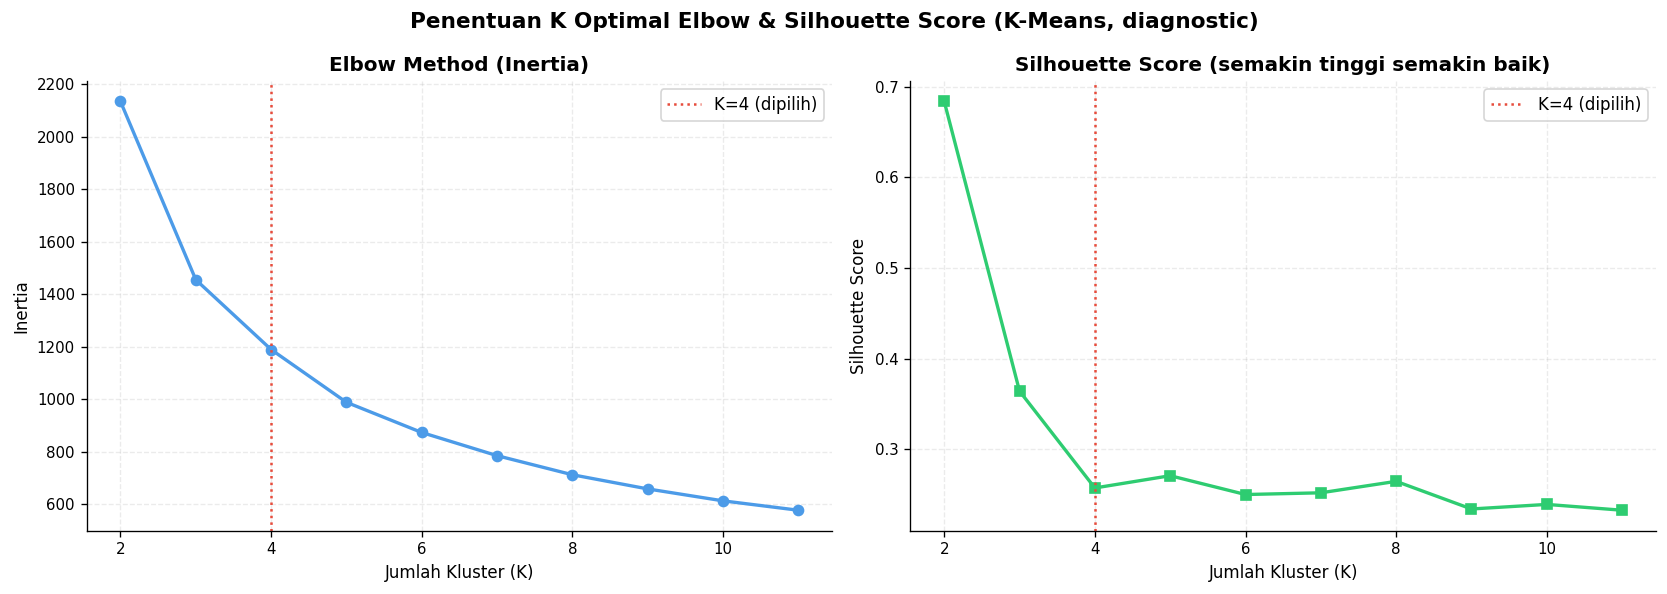

In [ ]:
k_range = range(2, 12)
inertias, sil_scores, db_scores = [], [], []

print('Menghitung metrik untuk K=2 hingga K=11 (K-Means, sebagai diagnostic eksplorasi K)...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    lbl = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, lbl))
    db_scores.append(davies_bouldin_score(Xs, lbl))

print(f'\n{"K":>3} | {"Inertia":>12} | {"Silhouette":>10} | {"Davies-Bouldin":>14}')
for i, k in enumerate(k_range):
    mark = ' <- dipilih' if k == 4 else ''
    print(f'{k:>3} {inertias[i]:>12.1f} {sil_scores[i]:>10.4f} {db_scores[i]:>14.4f}{mark}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Penentuan K Optimal Elbow & Silhouette Score (K-Means, diagnostic)', fontsize=13, fontweight='bold')

ax1.plot(k_range, inertias, color=PALETTE['blue'], marker='o', linewidth=2, markersize=6)
ax1.axvline(4, color=PALETTE['red'], linewidth=1.5, linestyle=':', label='K=4 (dipilih)')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Jumlah Kluster (K)')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(k_range, sil_scores, color=PALETTE['green'], marker='s', linewidth=2, markersize=6)
ax2.axvline(4, color=PALETTE['red'], linewidth=1.5, linestyle=':', label='K=4 (dipilih)')
ax2.set_title('Silhouette Score (semakin tinggi semakin baik)')
ax2.set_xlabel('Jumlah Kluster (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'elbow_silhouette.png'), bbox_inches='tight', dpi=120)
plt.show()

## Cell 7
## Model Final: Agglomerative Clustering K=4 dan Visualisasi Komprehensif

### Pembentukan Model Final
`CLUSTER_NAMES` mendefinisikan label deskriptif untuk tiap cluster (A-D) yang dipetakan ke angka 0-3 hasil clustering label ini yang dipakai konsisten di seluruh notebook mulai cell ini sampai akhir. `AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xs)` menjalankan clustering final berdasarkan keputusan yang sudah dijustifikasi di Cell 5 (silhouette & Davies-Bouldin terbaik dibanding KMeans/GMM).

### PCA untuk Visualisasi (bukan untuk Clustering)
`PCA(n_components=2)` di sini murni untuk keperluan visualisasi 2D mereduksi 6 dimensi fitur clustering jadi 2 komponen utama (PC1, PC2) yang bisa diplot di scatter plot. Clustering-nya sendiri tetap dijalankan di ruang fitur asli (`Xs`, 6 dimensi), bukan di ruang PCA supaya tidak kehilangan informasi yang mungkin ada di dimensi yang dibuang PCA.

### Empat Panel Visualisasi

| Panel | Isi | Detail Teknis |
|---|---|---|
| Kiri-atas | Scatter PCA 2D | Warna per cluster (`COLORS[k]`), judul menampilkan total varians yang dijelaskan PC1+PC2 |
| Kanan-atas | Radar chart profil cluster | `MinMaxScaler` dipakai supaya 6 fitur dengan skala berbeda (Rupiah vs persen vs slope) bisa dibandingkan pada sumbu radar yang sama; `angles += angles[:1]` menutup poligon radar supaya garisnya membentuk lingkaran penuh, bukan terputus |
| Kiri-bawah | Tren rata-rata GK per cluster sepanjang tahun | Rata-rata dihitung dari semua wilayah anggota tiap cluster (`wide.loc[wide.index.isin(wilayah_k)].mean()`) |
| Kanan-bawah | Pie chart proporsi jumlah wilayah per cluster | Menunjukkan seberapa seimbang/tidak seimbang ukuran keempat cluster |

Hasil clustering (termasuk koordinat PCA dan label cluster) disimpan ke `features_clustered.csv` file inilah yang jadi dasar untuk semua analisis lanjutan (forecasting per cluster, validasi eksternal, uji stabilitas).

Ringkasan tiap kluster (Agglomerative Ward, K=4):
    Kluster                              N      Mean GK     CAGR   Akselerasi
0 Kluster A - Menengah Stabil        374 Rp   369,366    5.47%       13,051
1 Kluster B - Menengah Akselerasi     20 Rp   363,294    6.85%       37,077
2 Kluster C - Tinggi Mapan           112 Rp   539,229    6.19%       13,389
3 Kluster D - Ekstrem Akselerasi       8 Rp   435,014    9.77%       76,161


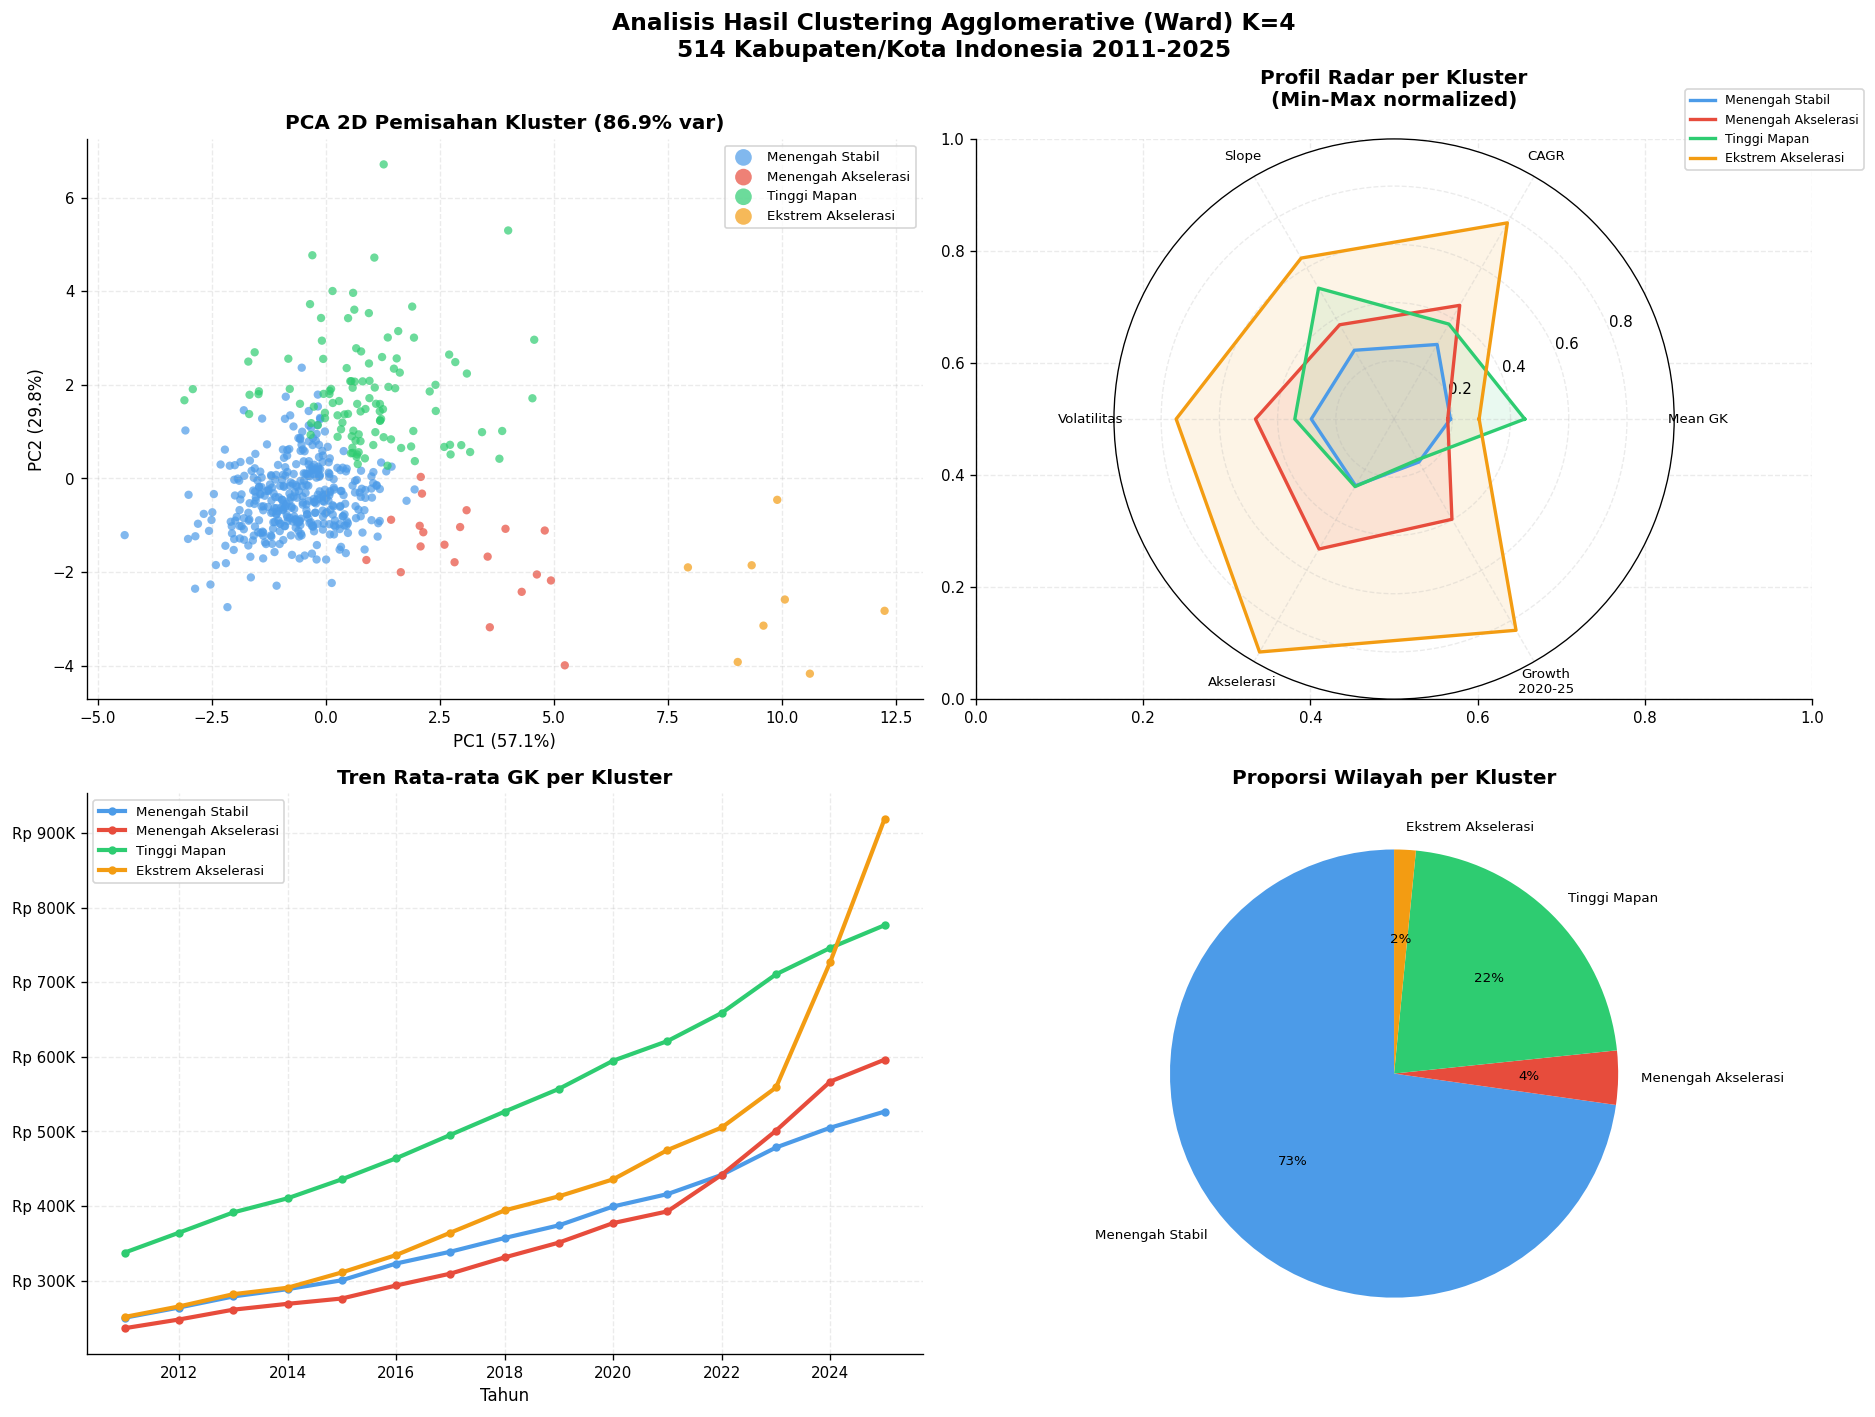

Clustering selesai. Plot tersimpan ke output folder.


In [ ]:
CLUSTER_NAMES = {
    0: 'Kluster A - Menengah Stabil',
    1: 'Kluster B - Menengah Akselerasi',
    2: 'Kluster C - Tinggi Mapan',
    3: 'Kluster D - Ekstrem Akselerasi'
}

K = 4
agglo_final = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels = agglo_final.fit_predict(Xs)
feats['cluster'] = labels
feats['cluster_name'] = feats['cluster'].map(CLUSTER_NAMES)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(Xs)
feats['pca1'] = X_pca[:,0]
feats['pca2'] = X_pca[:,1]

feats.to_csv(os.path.join(OUTPUT_DIR, 'features_clustered.csv'))

print('Ringkasan tiap kluster (Agglomerative Ward, K=4):')
print(f'{"" :>3} {"Kluster":<32} {"N":>5} {"Mean GK":>12} {"CAGR":>8} {"Akselerasi":>12}')
for k in range(K):
    mask = feats['cluster'] == k
    print(f'{k} {CLUSTER_NAMES[k]:<32} {mask.sum():>5} '
          f'Rp {feats[mask]["mean"].mean():>9,.0f} '
          f'{feats[mask]["cagr"].mean():>7.2f}% '
          f'{feats[mask]["acceleration"].mean():>12,.0f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Hasil Clustering Agglomerative (Ward) K=4\n514 Kabupaten/Kota Indonesia 2011-2025',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
for k in range(K):
    mask = feats['cluster'] == k
    ax.scatter(feats.loc[mask,'pca1'], feats.loc[mask,'pca2'],
               c=COLORS[k], label=CLUSTER_NAMES[k].split('-')[1].strip(), alpha=0.7, s=25, edgecolors='none')
ax.set_title(f'PCA 2D Pemisahan Kluster ({pca.explained_variance_ratio_.sum()*100:.1f}% var)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=2)

ax_radar = fig.add_subplot(2, 2, 2, projection='polar')
radar_labels = ['Mean GK','CAGR','Slope','Volatilitas','Akselerasi','Growth\n2020-25']
N_radar = len(CLUSTER_COLS)
angles = np.linspace(0, 2*np.pi, N_radar, endpoint=False).tolist()
angles += angles[:1]
X_radar = MinMaxScaler().fit_transform(feats[CLUSTER_COLS])
feats_radar = pd.DataFrame(X_radar, columns=CLUSTER_COLS, index=feats.index)
for k in range(K):
    vals = feats_radar[feats['cluster']==k][CLUSTER_COLS].mean().tolist()
    vals += vals[:1]
    ax_radar.plot(angles, vals, color=COLORS[k], linewidth=2, label=CLUSTER_NAMES[k].split('-')[1].strip())
    ax_radar.fill(angles, vals, color=COLORS[k], alpha=0.1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=8)
ax_radar.set_title('Profil Radar per Kluster\n(Min-Max normalized)', fontweight='bold', pad=20)
ax_radar.legend(fontsize=7.5, loc='upper right', bbox_to_anchor=(1.35, 1.1))

ax = axes[1, 0]
for k in range(K):
    mask = feats['cluster'] == k
    wilayah_k = feats[mask].index
    vals_k = wide.loc[wide.index.isin(wilayah_k), [str(y) for y in years]].mean()
    ax.plot(years, vals_k.values, color=COLORS[k], linewidth=2.5, marker='o',
            markersize=4, label=CLUSTER_NAMES[k].split('-')[1].strip())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e3:.0f}K'))
ax.legend(fontsize=8)
ax.set_title('Tren Rata-rata GK per Kluster')
ax.set_xlabel('Tahun')

ax = axes[1, 1]
sizes = [((feats['cluster']==k).sum()) for k in range(K)]
ax.pie(sizes, labels=[CLUSTER_NAMES[k].split('-')[1].strip() for k in range(K)],
       colors=COLORS, autopct='%1.0f%%', startangle=90,
       textprops={'fontsize': 8})
ax.set_title('Proporsi Wilayah per Kluster')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clustering_result.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Clustering selesai. Plot tersimpan ke output folder.')

**Interpretasi profil kluster (Agglomerative, Ward, K=4):**
- **Kluster A Menengah Stabil** (mayoritas wilayah): GK menengah, pertumbuhan moderat, volatilitas rendah. Wilayah dengan tren kemiskinan paling "normal" dan paling mudah diprediksi.
- **Kluster B Menengah Akselerasi**: GK menengah tapi akselerasi pertumbuhan jauh lebih tinggi dari Kluster A kandidat wilayah yang perlu dipantau karena berpotensi berpindah ke kategori lebih tinggi dalam beberapa tahun.
- **Kluster C Tinggi Mapan**: GK sudah tinggi secara level, biasanya kota besar/wilayah metropolitan dengan biaya hidup tinggi, pertumbuhan stabil.
- **Kluster D Ekstrem Akselerasi** (kluster terkecil, sekitar 8 wilayah): GK dan volatilitasnya jauh di atas kluster lain, dengan akselerasi pertumbuhan paling ekstrem. Ini bukan noise/outlier yang harus dibuang ini justru wilayah yang paling butuh perhatian kebijakan karena pola kenaikannya tidak biasa.

### Fitur mana yang paling menentukan pemisahan kluster?

1. **ANOVA F-statistic** per fitur = seberapa jauh rata-rata fitur ini berbeda antar 4 kluster (univariat, tidak memperhitungkan interaksi antar fitur).
2. **Random Forest surrogate** = latih model klasifikasi untuk menebak label kluster dari fitur, lalu baca `feature_importances_`-nya (menangkap interaksi antar fitur, karena Random Forest itu multivariat).
3. **PCA loadings** = kontribusi tiap fitur ke PC1/PC2 yang dipakai di scatter plot sebelumnya.

## Cell 8
## Feature Importance: Fitur Mana Paling Menentukan Pemisahan Kluster?

### Tujuan
Algoritma clustering (tidak seperti model supervised) tidak punya feature importance bawaan. Cell ini menjawab pertanyaan "fitur mana yang paling membedakan 4 cluster ini?" lewat **tiga metode independen sekaligus**, karena masing-masing menangkap aspek yang berbeda dan bisa saling melengkapi/mengonfirmasi.

### Metode 1 ANOVA F-statistic (univariat)
Untuk tiap fitur, `scipy.stats.f_oneway` membandingkan rata-rata fitur tersebut di keempat cluster. F-statistic yang lebih besar berarti fitur itu punya rata-rata yang jauh berbeda antar cluster relatif terhadap variasi di dalam cluster menandakan fitur tersebut kuat membedakan cluster **secara individual**, tanpa mempertimbangkan interaksi dengan fitur lain.

### Metode 2 Random Forest Surrogate (multivariat)
Trik umum untuk mendapatkan feature importance dari hasil clustering: latih model **supervised** (`RandomForestClassifier`) untuk menebak label cluster (`labels`) dari fitur asli (`Xs`), lalu baca `feature_importances_`-nya. Karena Random Forest menangkap interaksi antar fitur (bukan cuma efek satu-satu seperti ANOVA), urutan pentingnya fitur bisa berbeda dari Metode 1 perbedaan ini justru informatif, bukan kontradiksi.
`max_depth=5` sengaja dibatasi supaya model tidak terlalu kompleks untuk tugas interpretasi sederhana ini (bukan untuk prediksi baru), dan akurasi surrogate dicetak sebagai sanity check akurasi tinggi itu wajar dan diharapkan, karena modelnya memang "mencontek" pola label yang sudah ada, bukan memprediksi sesuatu yang baru.

### Metode 3 PCA Loadings
Memanfaatkan objek `pca` yang sudah di-fit di Cell 7: `pca.components_` menunjukkan seberapa besar kontribusi tiap fitur asli terhadap PC1 dan PC2 komponen yang dipakai di scatter plot visualisasi cluster sebelumnya.

### Visualisasi
Bar chart horizontal dari hasil Metode 2 (Random Forest), diurutkan dari fitur paling penting ke paling tidak penting, disimpan sebagai `feature_importance.png`.

Metode 1: ANOVA F-statistic per fitur
  growth_2020_2025     F=   544.97  p=1.31e-158
  acceleration         F=   284.11  p=2.21e-108
  slope                F=   278.06  p=6.72e-107
  mean                 F=   222.43  p=3.08e-92
  cv                   F=   141.71  p=8.82e-67
  cagr                 F=   118.09  p=4.46e-58

Metode 2: Random Forest surrogate (predict label kluster dari fitur)
Akurasi surrogate: 0.9942 (tinggi = wajar, model ini cuma alat bantu interpretasi bukan prediksi baru)
  slope                importance=0.3647
  mean                 importance=0.3018
  growth_2020_2025     importance=0.1001
  cagr                 importance=0.0878
  acceleration         importance=0.0870
  cv                   importance=0.0585

Metode 3: PCA loadings (PC1=57.1%, PC2=29.8%)
                    PC1    PC2
mean              0.139  0.681
cagr              0.482  0.061
slope             0.371  0.539
cv                0.506 -0.068
acceleration      0.399 -0.327
growth_2020_2025  0.442 -

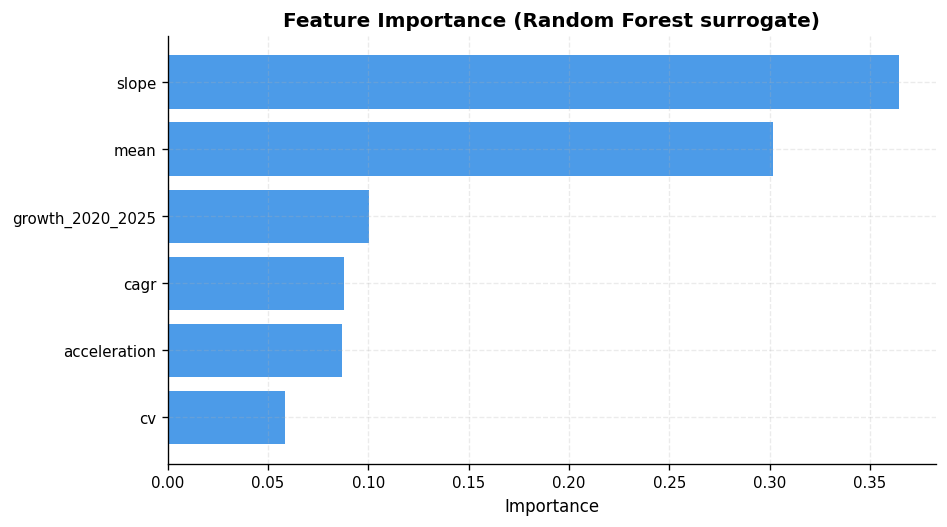

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('Metode 1: ANOVA F-statistic per fitur')
f_results = []
for i, col in enumerate(CLUSTER_COLS):
    groups = [Xs[labels==k, i] for k in range(K)]
    f, p = stats.f_oneway(*groups)
    f_results.append((col, f, p))
f_results.sort(key=lambda x: -x[1])
for col, f, p in f_results:
    print(f'  {col:<20} F={f:>9.2f}  p={p:.2e}')

print('\nMetode 2: Random Forest surrogate (predict label kluster dari fitur)')
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, max_depth=5)
rf.fit(Xs, labels)
acc = rf.score(Xs, labels)
print(f'Akurasi surrogate: {acc:.4f} (tinggi = wajar, model ini cuma alat bantu interpretasi bukan prediksi baru)')
importances = sorted(zip(CLUSTER_COLS, rf.feature_importances_), key=lambda x: -x[1])
for col, imp in importances:
    print(f'  {col:<20} importance={imp:.4f}')

print(f'\nMetode 3: PCA loadings (PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%)')
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_COLS, columns=['PC1','PC2'])
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8,4.5))
cols_sorted = [c for c,_ in importances]
vals_sorted = [v for _,v in importances]
ax.barh(cols_sorted[::-1], vals_sorted[::-1], color=PALETTE['blue'])
ax.set_title('Feature Importance (Random Forest surrogate)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:** dua metode ini memberi urutan yang sedikit berbeda, dan itu wajar bukan kontradiksi.
- **ANOVA** bilang `growth_2020_2025` (kenaikan pasca-pandemi) paling kuat memisahkan kluster secara individual.
- **Random Forest** bilang `slope` dan `mean` paling penting ketika mempertimbangkan interaksi antar fitur masuk akal karena level GK dan kecepatan kenaikannya saling terkait erat secara struktural (kluster "Tinggi Mapan" dan "Ekstrem Akselerasi" beda paling jelas justru dari kombinasi keduanya, bukan satu fitur saja).

Kesimpulan: **level GK (`mean`) dan tren jangka panjang (`slope`) adalah fondasi utama pemisahan kluster**, sementara `growth_2020_2025` dan `acceleration` berperan membedakan wilayah yang levelnya mirip tapi lintasannya beda arah (misalnya yang tadinya stabil lalu tiba-tiba melonjak pasca-2020). `cv` (volatilitas) konsisten jadi fitur dengan kontribusi paling kecil di kedua metode artinya keempat kluster ini terutama dibedakan oleh *level dan arah* pertumbuhan, bukan oleh *seberapa liar* fluktuasinya.

### 3.1 Tuning Hyperparameter Prophet: `changepoint_prior_scale`

Sebelum melatih model final, satu parameter Prophet yang paling berpengaruh `changepoint_prior_scale` (mengatur seberapa fleksibel model mengikuti perubahan tren) perlu dijustifikasi dengan angka, bukan dipilih sembarang. Nilai ini di-grid-search memakai skema rolling-origin CV yang sama seperti bagian robustness sebelumnya (3 fold, 4 kluster = 12 evaluasi per nilai kandidat), supaya pilihan akhirnya tidak overfit ke satu window evaluasi saja.

## Cell 9
## Tuning Hyperparameter Prophet: Grid Search `changepoint_prior_scale`

### Kenapa Parameter Ini yang Dituning?
`changepoint_prior_scale` adalah parameter Prophet yang paling berpengaruh terhadap hasil forecasting mengatur seberapa fleksibel model mengikuti perubahan tren (changepoint) di data historis. Nilai terlalu kecil membuat model kaku (underfitting tren), nilai terlalu besar membuat model terlalu leluasa mengikuti fluktuasi yang mungkin cuma noise (overfitting).

### Skema Evaluasi: Rolling-Origin Cross-Validation
`folds` mendefinisikan 3 pasangan train/test dengan window training yang makin panjang (expanding window) dan window test selalu 3 tahun meniru skenario forecasting nyata di mana model dilatih dengan data yang tersedia sampai suatu titik, lalu diuji ke periode berikutnya. Ini dipakai (bukan cuma satu kali split) supaya nilai `changepoint_prior_scale` yang dipilih tidak overfit ke satu window evaluasi tertentu.

### Proses Grid Search
Untuk tiap kandidat `cps` di `cps_grid` (0,01 sampai 3,0), model Prophet dilatih dan dievaluasi di ketiga fold × keempat cluster (total 12 evaluasi per nilai `cps`), lalu rata-rata MAPE-nya dicatat. Nilai `CPS` awalnya diambil dari titik minimum murni di grid (`min(cps_results, ...)`), namun kemudian **secara sadar di-override menjadi `CPS = 0.5`** di baris terakhir cell keputusan ini dijelaskan lebih lanjut di sel markdown setelah cell ini (intinya: penurunan MAPE dari 0,5 ke titik minimum grid sangat kecil/dalam rentang noise, sementara nilai yang terlalu tinggi berisiko overfitting terhadap fluktuasi historis, terutama untuk cluster dengan data terbatas).

### Visualisasi
Kurva MAPE vs `changepoint_prior_scale` (sumbu-X skala logaritmik karena rentang nilai kandidat sangat lebar) memperlihatkan secara visual di titik mana kurva mulai melandai (diminishing returns), yang jadi dasar argumen untuk tidak memilih titik minimum absolut.

INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


changepoint_prior_scale=0.01   avg MAPE (12 evaluasi) = 8.007%


INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


changepoint_prior_scale=0.05   avg MAPE (12 evaluasi) = 5.019%


INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


...

changepoint_prior_scale=0.8    avg MAPE (12 evaluasi) = 4.636%


INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


changepoint_prior_scale=1.5    avg MAPE (12 evaluasi) = 4.623%


INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


changepoint_prior_scale=3.0    avg MAPE (12 evaluasi) = 4.614%

Nilai terbaik murni dari grid: 3.0


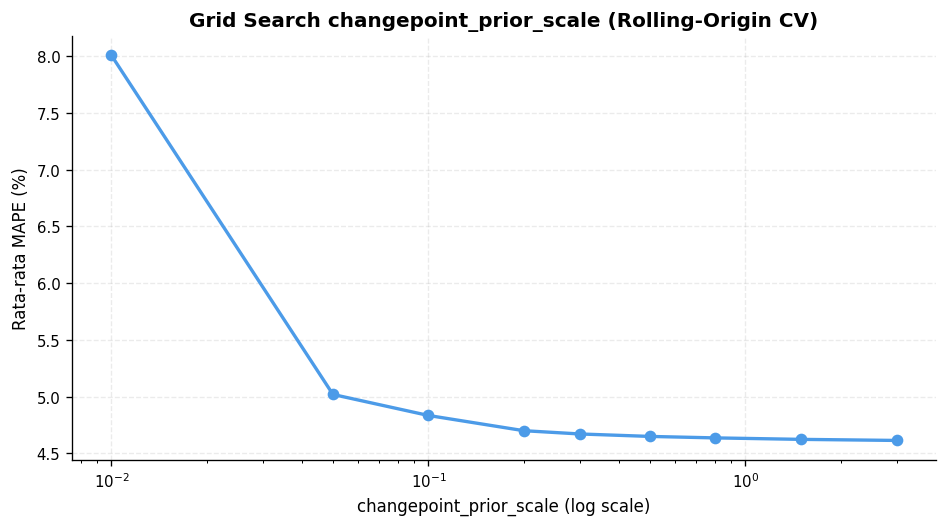


Nilai yang dipakai untuk model final: CPS = 0.5 (lihat penjelasan di sel markdown berikutnya)


In [ ]:
cps_grid = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.5, 3.0]

folds = [
    (list(range(2011,2017)), list(range(2017,2020))),
    (list(range(2011,2020)), list(range(2020,2023))),
    (list(range(2011,2023)), list(range(2023,2026))),
]

cps_results = []
for cps in cps_grid:
    fold_mapes = []
    for train_yrs, test_yrs in folds:
        for k in range(K):
            mask = feats['cluster'] == k
            wk = feats[mask].index
            full_vals = wide.loc[wide.index.isin(wk), [str(y) for y in years]].mean()
            train_y = full_vals[[str(y) for y in train_yrs]].values.astype(float)
            test_y = full_vals[[str(y) for y in test_yrs]].values.astype(float)
            df_train = pd.DataFrame({'ds': pd.to_datetime([f'{y}-01-01' for y in train_yrs]), 'y': train_y})
            m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=cps)
            m.fit(df_train)
            future = m.make_future_dataframe(periods=len(test_yrs), freq='YS')
            fc = m.predict(future)
            pred_y = fc[fc['ds'].dt.year.isin(test_yrs)]['yhat'].values
            fold_mapes.append(np.mean(np.abs((test_y - pred_y) / test_y)) * 100)
    cps_results.append((cps, np.mean(fold_mapes)))
    print(f'changepoint_prior_scale={cps:<6} avg MAPE (12 evaluasi) = {cps_results[-1][1]:.3f}%')

CPS = min(cps_results, key=lambda x: x[1])[0]
print(f'\nNilai terbaik murni dari grid: {CPS}')

fig, ax = plt.subplots(figsize=(8,4.5))
xs_plot = [r[0] for r in cps_results]
ys_plot = [r[1] for r in cps_results]
ax.plot(xs_plot, ys_plot, marker='o', color=PALETTE['blue'], linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('changepoint_prior_scale (log scale)')
ax.set_ylabel('Rata-rata MAPE (%)')
ax.set_title('Grid Search changepoint_prior_scale (Rolling-Origin CV)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cps_tuning.png'), bbox_inches='tight', dpi=120)
plt.show()

CPS = 0.5
print(f'\nNilai yang dipakai untuk model final: CPS = {CPS} (lihat penjelasan di sel markdown berikutnya)')

**Kenapa bukan langsung pakai nilai minimum di grid (0,8–3,0), padahal MAPE-nya sedikit lebih rendah?**

Kurva menunjukkan penurunan MAPE paling curam terjadi dari 0,01 → 0,3, lalu **melandai drastis** setelah 0,3 perbedaan MAPE dari 0,5 sampai 3,0 cuma sekitar 0,02–0,03 poin persen di semua kluster, praktis dalam rentang noise. Prophet sendiri secara desain memperingatkan bahwa `changepoint_prior_scale` yang terlalu tinggi membuat model terlalu leluasa mengikuti fluktuasi tren historis, meningkatkan risiko overfitting pada perubahan tren yang sebenarnya cuma noise terutama berisiko untuk Kluster D yang datanya sedikit (~8 wilayah) dan sudah volatil secara inheren.

**Keputusan: `CPS = 0.5`** hampir seluruh perbaikan akurasi yang bisa didapat dari tuning ini sudah tercapai di titik ini, tanpa mengambil risiko fleksibilitas berlebih yang manfaatnya sudah menyentuh titik jenuh (diminishing returns). Ini pengganti nilai 0,3 yang dipakai di iterasi sebelumnya sekarang dengan bukti kuantitatif di baliknya, bukan cuma "nilai yang kelihatannya jalan baik."

## Cell 10
## Training Model Prophet per Kluster dan Forecasting 2026-2028

### Alur Proses
Untuk tiap 4 cluster, deret waktu yang dipakai sebagai input Prophet adalah **rata-rata GK seluruh wilayah anggota cluster tersebut** (`wide.loc[wide.index.isin(wilayah_k)].mean()`) bukan tiap wilayah individual karena forecasting per cluster merepresentasikan tren agregat segmen tersebut, konsisten dengan tujuan segmentasi kebijakan yang ditarget per kelompok wilayah, bukan per wilayah tunggal.

### Format Data untuk Prophet
Prophet mensyaratkan input dataframe dengan kolom bernama persis `ds` (tanggal) dan `y` (nilai target) karenanya tahun dikonversi jadi format tanggal (`f'{y}-01-01'`) meski data aslinya cuma granularitas tahunan.

### Konfigurasi Model
- `yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False` seluruh komponen musiman bawaan Prophet dimatikan karena data ini granularitas **tahunan** (satu titik per tahun), jadi konsep "musiman dalam setahun" tidak relevan/tidak bisa dideteksi dari data seperti ini.
- `changepoint_prior_scale=CPS` memakai nilai 0,5 yang sudah dijustifikasi lewat grid search di Cell 9.
- `seasonality_mode='additive'` mode default Prophet, sesuai karena tidak ada komponen musiman yang aktif di model ini.

### Forecasting
`make_future_dataframe(periods=3, freq='YS')` memperpanjang deret waktu 3 tahun ke depan (2026-2028) dengan frekuensi awal tahun (`YS` = Year Start). Hasil prediksi (`yhat`) beserta interval ketidakpastian 95% (`yhat_lower`, `yhat_upper`) disimpan di dictionary `prophet_results`, dipakai lagi di Cell 12 untuk visualisasi.

In [ ]:
prophet_results = {}

print('Melatih model Prophet per kluster...')
for k in range(K):
    mask = feats['cluster'] == k
    wilayah_k = feats[mask].index
    vals = wide.loc[wide.index.isin(wilayah_k), [str(y) for y in years]].mean()

    df_p = pd.DataFrame({
        'ds': pd.to_datetime([f'{y}-01-01' for y in years]),
        'y' : vals.values.astype(float)
    })

    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=CPS,
        seasonality_mode='additive'
    )
    m.fit(df_p)
    future = m.make_future_dataframe(periods=3, freq='YS')
    fc = m.predict(future)

    prophet_results[k] = {
        'hist': df_p,
        'forecast': fc[['ds','yhat','yhat_lower','yhat_upper']]
    }

    pred_fc = fc[fc['ds'].dt.year >= 2026]
    print(f'\n  {CLUSTER_NAMES[k]} ({mask.sum()} wilayah)')
    for _, row in pred_fc.iterrows():
        print(f'{row["ds"].year}: Rp {row["yhat"]:,.0f}  '
              f'[{row["yhat_lower"]:,.0f} - {row["yhat_upper"]:,.0f}]')

INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


Melatih model Prophet per kluster...

  Kluster A - Menengah Stabil (374 wilayah)
2026: Rp 558,389  [554,506 - 562,032]
2027: Rp 586,628  [577,413 - 594,426]
2028: Rp 614,867  [598,677 - 628,897]


INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.



  Kluster B - Menengah Akselerasi (20 wilayah)
2026: Rp 658,027  [651,602 - 664,948]
2027: Rp 710,644  [699,453 - 722,273]
2028: Rp 763,262  [743,640 - 782,012]

  Kluster C - Tinggi Mapan (112 wilayah)
2026: Rp 820,327  [815,493 - 825,347]
2027: Rp 859,345  [850,289 - 870,325]
2028: Rp 898,362  [881,047 - 918,116]

  Kluster D - Ekstrem Akselerasi (8 wilayah)
2026: Rp 1,014,565  [987,918 - 1,041,197]
2027: Rp 1,147,407  [1,109,884 - 1,179,803]
2028: Rp 1,280,249  [1,226,211 - 1,328,725]


## Cell 11
## Evaluasi Model: Leave-Last-3-Out vs Baseline

### Skema Evaluasi
Untuk tiap cluster, 3 tahun terakhir (2023-2025) disisihkan sebagai data test (`test_y`), sementara model dilatih hanya dengan data sampai 2022 (`train_y`) pendekatan **leave-last-3-out** yang meniru skenario forecasting nyata: model tidak pernah "melihat" data yang sedang diprediksi.

### Tiga Model yang Dibandingkan
1. **Naive** prediksi = nilai terakhir data training diulang untuk 3 tahun ke depan (`np.repeat(train_y[-1], 3)`). Ini baseline paling sederhana yang mungkin; kalau model canggih tidak bisa mengalahkan ini, modelnya tidak berguna.
2. **Ekstrapolasi Linear** `scipy.stats.linregress` pada data training, lalu diproyeksikan lurus ke 3 tahun test. Baseline yang sedikit lebih canggih dari naive, menangkap tren linear sederhana.
3. **Prophet** model utama, dilatih ulang khusus dengan data training (terpisah dari model di Cell 10 yang dilatih dengan data penuh untuk forecasting produksi 2026-2028).

### Metrik Evaluasi
- **MAPE** (Mean Absolute Percentage Error) metrik utama, dinyatakan dalam persen sehingga mudah dibandingkan lintas cluster meski levelnya (Rupiah) berbeda jauh.
- **MAE** dan **RMSE** dihitung tambahan untuk model Prophet saja, memberi gambaran error dalam satuan Rupiah absolut.

Hasil lengkap (`eval_df`) disimpan ke `eval_metrics.csv` tabel inilah yang jadi bukti kuantitatif bahwa Prophet secara konsisten mengungguli kedua baseline di semua cluster.

In [ ]:
eval_rows = []

print('Evaluasi Leave-Last-3-Out: Prophet vs baseline (naive & linear extrapolation)')
print(f'\n{"Kluster":<32} {"Naive MAPE":>11} {"Linear MAPE":>12} {"Prophet MAPE":>13}')

for k in range(K):
    mask = feats['cluster'] == k
    wilayah_k = feats[mask].index
    vals = wide.loc[wide.index.isin(wilayah_k), [str(y) for y in years]].mean().values.astype(float)

    train_years = years[:-3]; train_y = vals[:-3]
    test_y = vals[-3:]

    # naive
    naive_pred = np.repeat(train_y[-1], 3)
    naive_mape = np.mean(np.abs((test_y - naive_pred) / test_y)) * 100

    # ekstrapolasi linear
    sl_b, intercept_b, *_ = stats.linregress(train_years, train_y)
    lin_pred = np.array([sl_b*y + intercept_b for y in years[-3:]])
    lin_mape = np.mean(np.abs((test_y - lin_pred) / test_y)) * 100

    # Prophet
    df_train = pd.DataFrame({
        'ds' : pd.to_datetime([f'{y}-01-01' for y in train_years]),
        'y' : train_y
    })
    m2 = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=CPS)
    m2.fit(df_train)
    future2 = m2.make_future_dataframe(periods=3, freq='YS')
    fc2 = m2.predict(future2)
    pred_y = fc2[fc2['ds'].dt.year.isin(years[-3:])]['yhat'].values

    mae = mean_absolute_error(test_y, pred_y)
    rmse = np.sqrt(mean_squared_error(test_y, pred_y))
    mape = np.mean(np.abs((test_y - pred_y) / test_y)) * 100
    eval_rows.append({
        'Kluster': CLUSTER_NAMES[k], 'N': mask.sum(),
        'Naive MAPE (%)': naive_mape, 'Linear MAPE (%)': lin_mape,
        'MAE': mae, 'RMSE': rmse, 'Prophet MAPE (%)': mape
    })

    print(f'{CLUSTER_NAMES[k]:<32} {naive_mape:>10.2f}% {lin_mape:>11.2f}% {mape:>12.2f}%')

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(os.path.join(OUTPUT_DIR, 'eval_metrics.csv'), index=False)
print('\nMetrik evaluasi tersimpan!')
eval_df

INFO:prophet:n_changepoints greater than number of observations. Using 8.


Evaluasi Leave-Last-3-Out: Prophet vs baseline (naive & linear extrapolation)

Kluster                           Naive MAPE  Linear MAPE  Prophet MAPE
Kluster A - Menengah Stabil           12.10%        7.51%         3.73%


INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


Kluster B - Menengah Akselerasi       19.91%       19.36%        11.46%
Kluster C - Tinggi Mapan              11.37%        5.15%         2.75%
Kluster D - Ekstrem Akselerasi        28.38%       24.78%        20.31%

Metrik evaluasi tersimpan!


,Kluster,N,Naive MAPE (%),Linear MAPE (%),MAE,RMSE,Prophet MAPE (%)
0,Kluster A - Menengah Stabil,374,12.098117,7.511315,18831.678860,18948.816827,3.733572
1,Kluster B - Menengah Akselerasi,20,19.905007,19.361488,64501.935633,66934.939209,11.459694
2,Kluster C - Tinggi Mapan,112,11.373395,5.152975,20423.993888,20460.025036,2.748560
3,Kluster D - Ekstrem Akselerasi,8,28.383937,24.776491,167608.142095,206948.943264,20.306513


**Interpretasi:** Prophet secara konsisten mengungguli kedua baseline (naive dan ekstrapolasi linear) di semua kluster ini bukti bahwa model time series yang dipakai benar-benar memberi nilai tambah, bukan cuma "ikut tren" yang bisa didapat dari model sederhana.

## Cell 12
## Visualisasi Hasil Forecasting

### Struktur Grid
5 dari 6 slot grid 2×3 dipakai untuk menampilkan hasil per cluster secara individual (loop `for k in range(K)`, ditempatkan di `axes[k // 2, k % 2]`), dan slot terakhir (kanan-bawah, `axes[1, 2]`) menampilkan perbandingan keempat cluster sekaligus dalam satu grafik.

### Elemen Visual per Panel Cluster
- **Area bayangan (`fill_between`)** interval ketidakpastian 95% (`yhat_lower` sampai `yhat_upper`), hanya ditampilkan untuk bagian prediksi (`fc_years >= 2025`) supaya tidak menutupi garis historis.
- **Garis solid + marker bulat** data historis aktual (`hist['y']`).
- **Garis putus-putus** nilai `yhat` Prophet di seluruh rentang waktu (termasuk fitted value untuk periode historis, berguna untuk mengecek seberapa baik model "menjejaki" data yang sudah diketahui).
- **Marker lingkaran putih dengan tepi berwarna** titik prediksi murni 2026-2028, dibuat visually berbeda dari garis fitted supaya jelas mana yang benar-benar prediksi masa depan.
- **Anotasi teks** nilai prediksi ditulis langsung di atas tiap titik prediksi (format `Rp {nilai}K`) supaya angka bisa langsung dibaca tanpa perlu menghitung dari sumbu-Y.
- **Garis vertikal putus-putus abu-abu** di `2025.5` penanda batas antara data historis dan periode prediksi.

### Panel Perbandingan (kanan-bawah)
Menumpuk keempat cluster dalam satu sumbu yang sama (skala Rupiah ribu) untuk memudahkan perbandingan relatif garis solid+lingkaran untuk historis, garis putus+kotak untuk prediksi, warna konsisten dengan `COLORS` yang sama dipakai di seluruh notebook.

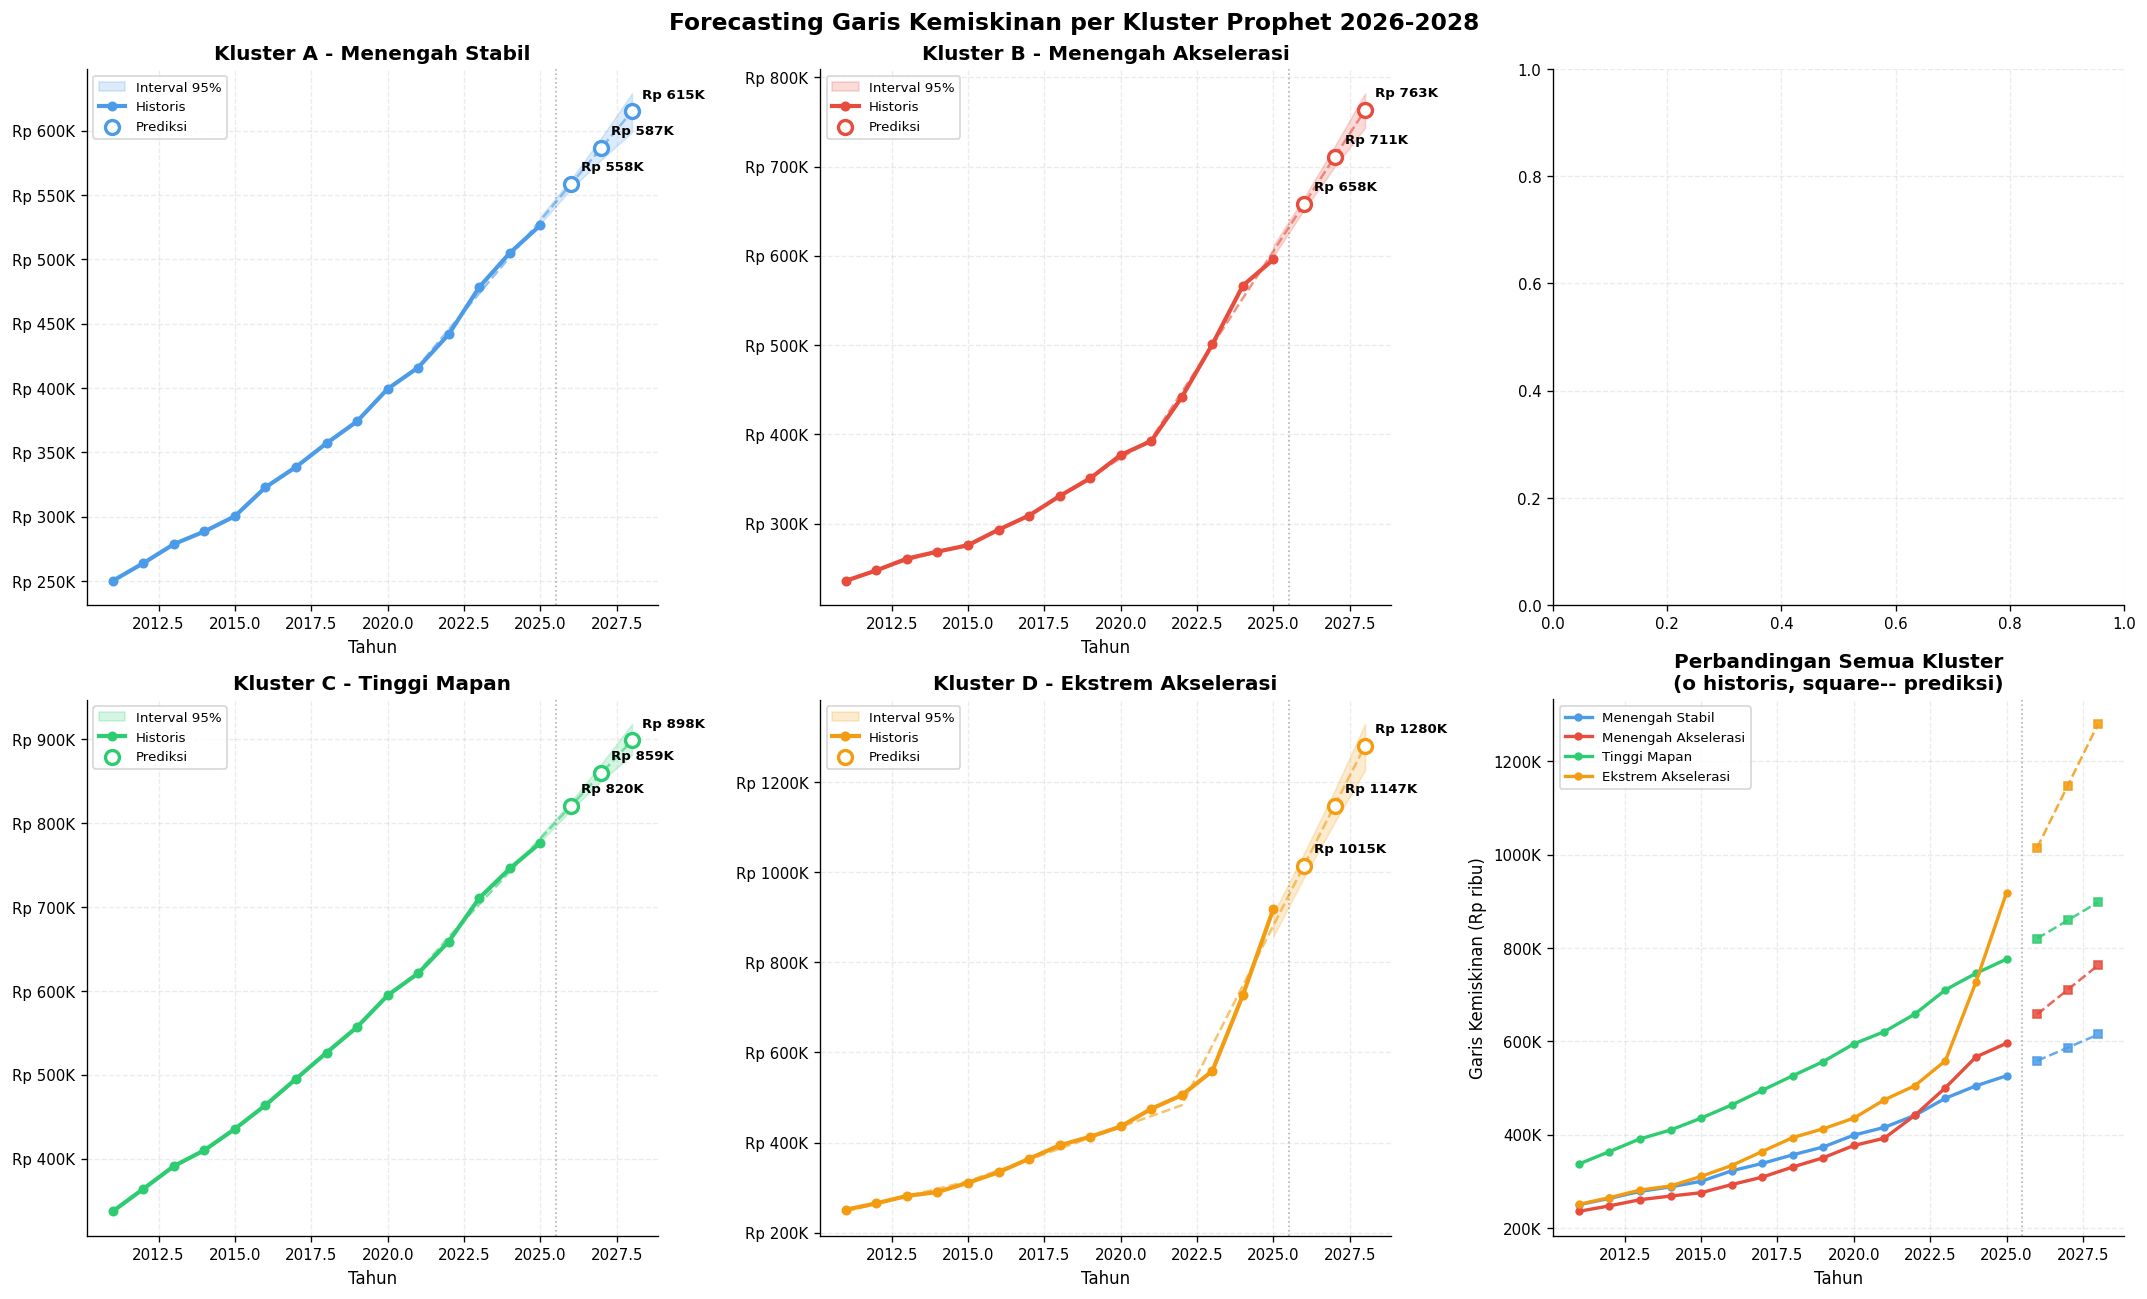

Visualisasi forecasting selesai!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Forecasting Garis Kemiskinan per Kluster Prophet 2026-2028', fontsize=14, fontweight='bold')

for k in range(K):
    ax = axes[k // 2, k % 2]
    hist = prophet_results[k]['hist']
    fc = prophet_results[k]['forecast']
    fc_years = fc['ds'].dt.year.values
    color = COLORS[k]

    pred_mask = fc_years >= 2025
    ax.fill_between(fc_years[pred_mask],
                    fc[pred_mask]['yhat_lower'].values,
                    fc[pred_mask]['yhat_upper'].values,
                    alpha=0.2, color=color, label='Interval 95%')

    ax.plot(hist['ds'].dt.year, hist['y'], 'o-', color=color, linewidth=2.5, markersize=5, label='Historis')
    ax.plot(fc_years, fc['yhat'].values, '--', color=color, linewidth=1.5, alpha=0.6)

    pred_fc = fc[fc_years >= 2026]
    ax.scatter(pred_fc['ds'].dt.year, pred_fc['yhat'],
               color='white', s=70, zorder=5, edgecolors=color, linewidth=2, label='Prediksi')
    for _, row in pred_fc.iterrows():
        ax.annotate(f"Rp {row['yhat']/1e3:.0f}K",
                    (row['ds'].year, row['yhat']),
                    textcoords='offset points', xytext=(6, 8), fontsize=8, fontweight='bold')

    ax.axvline(2025.5, color='gray', linewidth=1, linestyle=':', alpha=0.6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e3:.0f}K'))
    ax.set_title(CLUSTER_NAMES[k])
    ax.set_xlabel('Tahun')
    ax.legend(fontsize=8)

ax = axes[1, 2]
for k in range(K):
    hist = prophet_results[k]['hist']
    fc = prophet_results[k]['forecast']
    fc_years = fc['ds'].dt.year.values
    ax.plot(hist['ds'].dt.year, hist['y']/1e3, 'o-', color=COLORS[k], linewidth=2, markersize=4, label=CLUSTER_NAMES[k].split('-')[1].strip())
    pm = fc_years >= 2026
    ax.plot(fc_years[pm], fc[pm]['yhat'].values/1e3, 's--', color=COLORS[k], linewidth=1.5, markersize=5, alpha=0.85)
ax.axvline(2025.5, color='gray', linewidth=1, linestyle=':', alpha=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.set_title('Perbandingan Semua Kluster\n(o historis, square-- prediksi)')
ax.set_xlabel('Tahun')
ax.set_ylabel('Garis Kemiskinan (Rp ribu)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'forecasting_result.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Visualisasi forecasting selesai!')

## 4. Pengayaan Data Eksternal: IPM & Persentase Penduduk Miskin

Untuk memperkuat analisis, notebook ini menggabungkan dua sumber BPS tambahan:
- **Persentase Penduduk Miskin (P0)** per kab/kota, 2011–2025 beda dimensi dari Garis Kemiskinan: ini persentase *jumlah orang* di bawah garis kemiskinan, bukan nilai rupiah garisnya.
- **Indeks Pembangunan Manusia (IPM)** per kab/kota, tersedia 2011–2013 saja (BPS mengubah metodologi IPM setelah itu, jadi rentang datanya tidak sepanjang GK). Karena rentangnya pendek, IPM dipakai sebagai **fitur snapshot** (rata-rata awal periode), bukan fitur pertumbuhan.

## Cell 13
## Load Data Eksternal: Persentase Penduduk Miskin dan IPM

### Tujuan
Memperkaya analisis dengan dua sumber BPS tambahan di luar Garis Kemiskinan: **Persentase Penduduk Miskin** (2011-2025, format sama seperti GK) dan **Indeks Pembangunan Manusia/IPM** (2011-2013 saja, karena BPS mengubah metodologi IPM setelah itu).

### `ALIAS_IPM`: Kenapa Perlu Peta Alias Manual?
File IPM BPS punya dua perbedaan format dibanding GK/Persentase Miskin: **(1)** semua nama wilayah ditulis huruf kapital penuh (termasuk kabupaten/kota, bukan cuma provinsi), dan **(2)** sejumlah wilayah masih pakai nama lama dari periode 2011-2013, sebelum pemekaran/pergantian nama daerah (contoh: `PASIR` yang sekarang bernama *Paser*, `PONTIANAK` yang sekarang bernama *Mempawah*, `KODYA JAKARTA BARAT` yang sekarang ditulis *Kota Jakarta Barat*). Dictionary ini memetakan 14 nama lama tersebut secara eksplisit ke nama kanonis yang dipakai di `wide` (data GK), supaya proses pencocokan wilayah tidak kehilangan data akibat perbedaan penulisan semata.

### Proses Loading Persentase Penduduk Miskin
Identik dengan Cell 2 (load GK): baca 15 file, filter baris provinsi lewat cek huruf kapital, pivot ke wide format, isi nilai kosong dengan interpolasi + forward/backward fill.

### Proses Loading IPM (Lebih Rumit)
1. Baris `INDONESIA` (agregat nasional) dibuang secara eksplisit beda dari GK/Persentase Miskin yang tidak punya baris semacam ini.
2. `canonical_map` dibangun dari nama wilayah di `wide.index` (data GK, sudah title-case dan konsisten), dipetakan lewat versi huruf besarnya.
3. Untuk tiap baris IPM, dicoba dulu pencocokan lewat `ALIAS_IPM` (nama lama → nama baru), baru kalau tidak ada di situ, dicoba pencocokan langsung case-insensitive lewat `canonical_map`. Logika `.map(ALIAS_IPM).fillna(wilayah_upper.map(canonical_map))` inilah yang menjalankan strategi "coba alias dulu, baru fallback ke pencocokan langsung" tersebut dalam satu baris.

Kedua dataset yang berhasil diproses disimpan ke `persentase_miskin_wide.csv` dan `ipm_wide.csv`.

In [ ]:
ALIAS_IPM = {
    'BULONGAN': 'Bulungan',
    'DHARMAS RAYA': 'Dharmasraya',
    'KODYA JAKARTA BARAT': 'Kota Jakarta Barat',
    'KODYA JAKARTA PUSAT': 'Kota Jakarta Pusat',
    'KODYA JAKARTA SELATAN': 'Kota Jakarta Selatan',
    'KODYA JAKARTA TIMUR': 'Kota Jakarta Timur',
    'KODYA JAKARTA UTARA': 'Kota Jakarta Utara',
    'KOTA BAU-BAU': 'Kota Baubau',
    'KOTA PARE-PARE': 'Kota Parepare',
    'KARANG ASEM': 'Karangasem',
    'PASIR': 'Paser',
    'PONTIANAK': 'Mempawah',
    'PUNJAK JAYA': 'Puncak Jaya',
    'TULANGBAWANG BARAT': 'Tulang Bawang Barat',
}

files_pm = sorted(glob.glob(os.path.join(DATA_DIR, 'Percentage*Population*Poverty*Regency*Municipality*.csv')))
dfs_pm = []
for f in files_pm:
    year = int(re.search(r'(\d{4})', os.path.basename(f)).group(1))
    d = pd.read_csv(f, skiprows=2, header=None, names=['wilayah','persen_miskin'], encoding='utf-8-sig')
    d['tahun'] = year
    d = d.dropna(subset=['wilayah'])
    d = d[d['wilayah'].str.strip() != '']
    dfs_pm.append(d)
combined_pm = pd.concat(dfs_pm, ignore_index=True)
combined_pm['wilayah'] = combined_pm['wilayah'].str.strip()
combined_pm['persen_miskin'] = pd.to_numeric(combined_pm['persen_miskin'].replace('-', np.nan), errors='coerce')
combined_pm['is_provinsi'] = combined_pm['wilayah'].str.upper() == combined_pm['wilayah']
kabkota_pm = combined_pm[~combined_pm['is_provinsi']].copy()
pivot_pm = kabkota_pm.pivot_table(index='wilayah', columns='tahun', values='persen_miskin', aggfunc='first')
pivot_pm.columns = pivot_pm.columns.astype(str)
wide_pm = pivot_pm.interpolate(axis=1, method='linear').ffill(axis=1).bfill(axis=1)
print(f'Persentase Penduduk Miskin: {wide_pm.shape[0]} wilayah, tahun {wide_pm.columns[0]}-{wide_pm.columns[-1]}')

files_ipm = sorted(glob.glob(os.path.join(DATA_DIR, 'Indeks*Pembangunan*Manusia*Menurut*Kabupaten*Kota*.csv')))
dfs_ipm = []
for f in files_ipm:
    year = int(re.search(r'(\d{4})', os.path.basename(f)).group(1))
    d = pd.read_csv(f, skiprows=2, header=None, names=['wilayah','ipm'], encoding='utf-8-sig')
    d['tahun'] = year
    d = d.dropna(subset=['wilayah'])
    d = d[d['wilayah'].str.strip() != '']
    dfs_ipm.append(d)
combined_ipm = pd.concat(dfs_ipm, ignore_index=True)
combined_ipm['wilayah'] = combined_ipm['wilayah'].str.strip()
combined_ipm['ipm'] = pd.to_numeric(combined_ipm['ipm'].replace('-', np.nan), errors='coerce')
combined_ipm = combined_ipm[combined_ipm['wilayah'].str.upper() != 'INDONESIA']

canonical_map = {name.upper(): name for name in wide.index}
wilayah_upper = combined_ipm['wilayah'].str.upper()
combined_ipm['wilayah_canonical'] = wilayah_upper.map(ALIAS_IPM).fillna(wilayah_upper.map(canonical_map))
matched_ipm = combined_ipm.dropna(subset=['wilayah_canonical'])
print(f'IPM: {matched_ipm["wilayah_canonical"].nunique()}/{wide.shape[0]} kab/kota berhasil dicocokkan')

pivot_ipm = matched_ipm.pivot_table(index='wilayah_canonical', columns='tahun', values='ipm', aggfunc='first')
pivot_ipm.columns = [f'ipm_{c}' for c in pivot_ipm.columns]

wide_pm.to_csv(os.path.join(OUTPUT_DIR, 'persentase_miskin_wide.csv'))
pivot_ipm.to_csv(os.path.join(OUTPUT_DIR, 'ipm_wide.csv'))


Persentase Penduduk Miskin: 514 wilayah, tahun 2011-2025
IPM: 514/514 kab/kota berhasil dicocokkan


## Cell 14
## Fitur Tambahan dari Data Eksternal

### Fitur dari Persentase Penduduk Miskin (Paralel dengan Fitur GK)
Karena data ini mencakup rentang penuh 2011-2025 (sama seperti GK), fitur yang dibangun mengikuti pola yang sama seperti di Cell 4: `pm_mean` (level rata-rata), `pm_cagr` (laju pertumbuhan tahunan majemuk), dan `pm_slope` (kemiringan tren linear via `linregress` per wilayah, dengan loop yang sama seperti fitur `slope` pada GK).

### Fitur dari IPM (Snapshot, Bukan Tren)
Karena IPM cuma tersedia 2011-2013 (rentang terlalu pendek untuk menghitung tren yang bermakna), fitur yang dibangun cuma `ipm_avg_1113` rata-rata sederhana dari 3 tahun yang tersedia, diperlakukan sebagai **snapshot kondisi awal periode**, bukan sebagai indikator pertumbuhan.
`.reindex(feats.index)` menyelaraskan data IPM (yang index-nya dari hasil matching di Cell 13, mungkin tidak 100% match dengan seluruh wilayah di `feats`) ke urutan wilayah yang sama dengan `feats`. Wilayah yang tidak berhasil di-match sebelumnya akan bernilai `NaN` di titik ini, sehingga `.fillna(median)` mengisi kekosongan tersebut dengan nilai tengah dari wilayah lain yang datanya lengkap pendekatan konservatif yang tidak mendistorsi arah kluster secara sistematis.

### Cek Korelasi
Baris terakhir menampilkan matriks korelasi antara 6 fitur clustering utama (`CLUSTER_COLS`) dengan 4 fitur eksternal baru pengecekan awal untuk melihat apakah fitur-fitur baru ini membawa informasi yang benar-benar baru (korelasi rendah) atau cuma mengulang informasi yang sudah ada (korelasi tinggi), sebagai bekal sebelum eksperimen di Cell 15.

In [ ]:
feats['pm_mean'] = wide_pm.mean(axis=1)
feats['pm_cagr'] = ((wide_pm['2025'] / wide_pm['2011']) ** (1/14) - 1) * 100
pm_slopes = []
for idx in wide_pm.index:
    row = wide_pm.loc[idx].values.astype(float)
    sl, *_ = stats.linregress(years_np, row)
    pm_slopes.append(sl)
feats['pm_slope'] = pm_slopes

feats['ipm_avg_1113'] = pivot_ipm.mean(axis=1).reindex(feats.index)
feats['ipm_avg_1113'] = feats['ipm_avg_1113'].fillna(feats['ipm_avg_1113'].median())

print('Fitur eksternal ditambahkan ke feats. Cek korelasi dengan fitur clustering utama:')
extra_cols = ['pm_mean','pm_cagr','pm_slope','ipm_avg_1113']
print(feats[CLUSTER_COLS + extra_cols].corr().loc[CLUSTER_COLS, extra_cols].round(2))

Fitur eksternal ditambahkan ke feats. Cek korelasi dengan fitur clustering utama:
                  pm_mean  pm_cagr  pm_slope  ipm_avg_1113
mean                 0.04     0.03     -0.05          0.13
cagr                 0.15     0.16      0.10         -0.29
slope                0.09     0.13      0.05         -0.02
cv                   0.16     0.16      0.09         -0.28
acceleration         0.32     0.01     -0.17         -0.35
growth_2020_2025     0.33     0.04     -0.12         -0.46


**Eksperimen: apakah menambahkan fitur eksternal ini ke clustering meningkatkan kualitasnya?**

Korelasi fitur eksternal dengan fitur clustering utama tergolong rendah (kebanyakan |r| < 0.3), jadi secara teori fitur ini membawa informasi baru yang tidak redundan. Tapi mari diuji langsung, bukan diasumsikan.

## Cell 15
## Eksperimen: Pengaruh Fitur Eksternal terhadap Kualitas Clustering

### Pertanyaan yang Dijawab
Apakah memasukkan fitur eksternal (Persentase Penduduk Miskin dan IPM) langsung sebagai **input clustering** bukan cuma sebagai variabel pelengkap akan meningkatkan kualitas segmentasi yang dihasilkan?

### Desain Eksperimen
`ENRICHED_COLS` menggabungkan 6 fitur GK-only (`CLUSTER_COLS`) dengan 4 fitur eksternal baru. Dua skenario dibandingkan berdampingan: clustering dengan fitur **GK-only (baseline)** vs clustering dengan fitur **enriched**, masing-masing diuji dengan dua algoritma (KMeans dan Agglomerative) di K=4, memakai metrik yang sama seperti Cell 5 (silhouette score dan Davies-Bouldin index).

### Kenapa Eksperimen Ini Penting
Ini menguji langsung asumsi umum "semakin banyak data yang dimasukkan, semakin baik modelnya" alih-alih diasumsikan begitu saja, cell ini membuktikannya dengan angka. Hasilnya (dijelaskan di sel markdown berikutnya) justru menunjukkan sebaliknya, akibat *curse of dimensionality* fenomena di mana menambah dimensi fitur tanpa menambah proporsi variansi yang relevan justru membuat jarak antar titik data menjadi kurang informatif secara relatif, sehingga struktur cluster menjadi kurang tegas meski masing-masing fitur baru secara individual tidak redundan.

In [ ]:
ENRICHED_COLS = CLUSTER_COLS + ['pm_mean', 'pm_cagr', 'pm_slope', 'ipm_avg_1113']

print('Perbandingan kualitas clustering: fitur GK-only vs fitur enriched (+ persen miskin + IPM)\n')
for label, cols in [('GK-only (baseline)', CLUSTER_COLS), ('Enriched (+ persen miskin + IPM)', ENRICHED_COLS)]:
    Xe = StandardScaler().fit_transform(feats[cols])
    lbl_km = KMeans(n_clusters=4, random_state=SEED, n_init=20).fit_predict(Xe)
    lbl_ag = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xe)
    print(f'{label}:')
    print(f'KMeans silhouette={silhouette_score(Xe, lbl_km):.4f}  db={davies_bouldin_score(Xe, lbl_km):.4f}')
    print(f'Agglomerative silhouette={silhouette_score(Xe, lbl_ag):.4f}  db={davies_bouldin_score(Xe, lbl_ag):.4f}')
    print()

Perbandingan kualitas clustering: fitur GK-only vs fitur enriched (+ persen miskin + IPM)

GK-only (baseline):
KMeans silhouette=0.2574  db=1.0943
Agglomerative silhouette=0.3865  db=0.8951

Enriched (+ persen miskin + IPM):
KMeans silhouette=0.1724  db=1.4458
Agglomerative silhouette=0.1785  db=1.4639



**Hasil dan keputusan:** menambahkan fitur eksternal langsung ke input clustering justru **menurunkan** silhouette score (dari ~0,39 menjadi ~0,18 pada Agglomerative) bukan menaikkan. Ini konsekuensi *curse of dimensionality*: menambah dimensi tanpa menambah proporsi variansi yang relevan membuat jarak antar titik makin "rata," sehingga struktur cluster jadi kurang tegas, meski masing-masing fitur baru secara individual tidak redundan dengan fitur lama.

**Keputusan metodologis:** clustering final tetap memakai 6 fitur GK-only (seperti bagian sebelumnya), karena secara terukur memberi struktur kluster paling jelas. IPM dan Persentase Penduduk Miskin dipakai bukan sebagai *input* clustering, melainkan sebagai **variabel validasi eksternal** untuk mengecek apakah kluster yang terbentuk murni dari pola GK ini benar-benar berbeda secara substansi sosial-ekonomi, bukan cuma artefak matematis. Ini pendekatan yang lebih jujur dan lebih kuat secara metodologis daripada memaksakan semua fitur masuk clustering demi kelihatan "lebih kaya data."

## Cell 16
## Validasi Eksternal Kluster via Uji ANOVA

### Konsep Validasi Eksternal
Karena fitur eksternal (IPM, Persentase Penduduk Miskin) **tidak** dipakai sebagai input clustering (keputusan dari Cell 15), keduanya sekarang punya peran berbeda: menjadi alat **validasi independen** mengecek apakah 4 cluster yang terbentuk murni dari pola GK ternyata juga berbeda secara nyata dalam dua indikator yang sama sekali tidak dilihat model saat membentuk cluster. Kalau iya, itu bukti kuat bahwa cluster ini menangkap kondisi sosial-ekonomi riil, bukan cuma artefak matematis dari 6 angka yang dipakai membentuknya.

### Perhitungan
Untuk tiap cluster, dihitung rata-rata `ipm_avg_1113` dan `pm_mean` dari seluruh wilayah anggotanya angka-angka ini yang pertama dicetak sebagai tabel ringkasan.

### Uji ANOVA (`f_oneway`)
Uji statistik formal untuk menjawab: apakah perbedaan rata-rata IPM/Persentase Miskin antar 4 cluster ini signifikan secara statistik, atau bisa jadi cuma kebetulan? `f_oneway` menerima 4 grup data (satu per cluster) dan mengembalikan F-statistic beserta p-value; **p < 0,05** secara konvensi dianggap signifikan dicek eksplisit lewat kondisi `if p_ipm<0.05` di baris print, supaya kesimpulan "signifikan/tidak signifikan" tercetak otomatis, bukan perlu dibaca manual dari angka p-value mentah.

### Visualisasi
Boxplot berdampingan untuk kedua variabel, satu boxplot per cluster cara visual paling langsung untuk melihat apakah sebaran nilai antar cluster benar-benar terpisah (tidak banyak overlap) atau tumpang tindih.

Rata-rata IPM (2011-2013) dan Persentase Penduduk Miskin per kluster (validasi eksternal):
Kluster                              N    IPM avg   Persen Miskin
Kluster A - Menengah Stabil        374      71.56          12.20%
Kluster B - Menengah Akselerasi     20      70.20          12.55%
Kluster C - Tinggi Mapan           112      73.16          12.11%
Kluster D - Ekstrem Akselerasi       8      51.12          36.11%

Uji ANOVA - apakah perbedaan antar kluster signifikan secara statistik?
IPM: F=59.02, p=9.19e-33 (signifikan)
Persentase Miskin : F=29.04, p=2.39e-17 (signifikan)


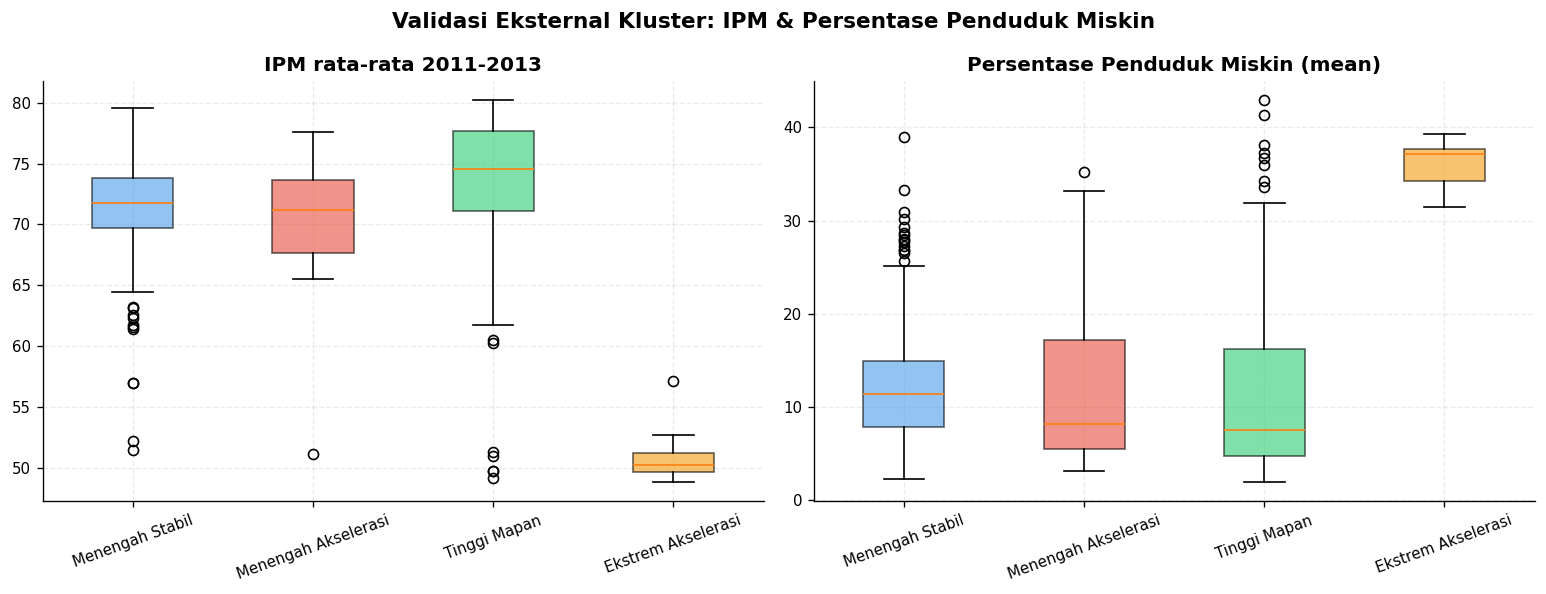

In [ ]:
print('Rata-rata IPM (2011-2013) dan Persentase Penduduk Miskin per kluster (validasi eksternal):')
print(f'{"Kluster":<32} {"N":>5} {"IPM avg":>10} {"Persen Miskin":>15}')
for k in range(K):
    mask = feats['cluster'] == k
    print(f'{CLUSTER_NAMES[k]:<32} {mask.sum():>5} {feats[mask]["ipm_avg_1113"].mean():>10.2f} {feats[mask]["pm_mean"].mean():>14.2f}%')

groups_ipm = [feats[feats['cluster']==k]['ipm_avg_1113'].dropna() for k in range(K)]
groups_pm = [feats[feats['cluster']==k]['pm_mean'].dropna() for k in range(K)]
f_ipm, p_ipm = stats.f_oneway(*groups_ipm)
f_pm, p_pm = stats.f_oneway(*groups_pm)
print(f'\nUji ANOVA - apakah perbedaan antar kluster signifikan secara statistik?')
print(f'IPM: F={f_ipm:.2f}, p={p_ipm:.2e} {"(signifikan)" if p_ipm<0.05 else "(tidak signifikan)"}')
print(f'Persentase Miskin : F={f_pm:.2f}, p={p_pm:.2e} {"(signifikan)" if p_pm<0.05 else "(tidak signifikan)"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validasi Eksternal Kluster: IPM & Persentase Penduduk Miskin', fontsize=13, fontweight='bold')
for ax, col, title in [(axes[0], 'ipm_avg_1113', 'IPM rata-rata 2011-2013'), (axes[1], 'pm_mean', 'Persentase Penduduk Miskin (mean)')]:
    data_box = [feats[feats['cluster']==k][col].dropna().values for k in range(K)]
    bp = ax.boxplot(data_box, labels=[CLUSTER_NAMES[k].split('-')[1].strip() for k in range(K)], patch_artist=True)
    for patch, c in zip(bp['boxes'], COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'external_validation.png'), bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi validasi eksternal:** perbedaan IPM dan Persentase Penduduk Miskin antar kluster **signifikan secara statistik** (ANOVA p < 0,001 untuk keduanya). Kluster D (Ekstrem Akselerasi) yang terbentuk murni dari pola pertumbuhan GK ternyata juga memiliki IPM jauh lebih rendah dan persentase penduduk miskin jauh lebih tinggi dibanding tiga kluster lain. Ini bukti kuat bahwa segmentasi yang dihasilkan bukan cuma pengelompokan matematis dari satu variabel, tapi menangkap kondisi sosial-ekonomi riil yang tervalidasi oleh dua indikator independen. Temuan ini memperkuat justifikasi rekomendasi kebijakan: Kluster D benar-benar layak mendapat prioritas intervensi khusus, bukan cuma karena angkanya ekstrem secara statistik.

## 5. Uji Robustness: Stabilitas Kluster & Rolling Cross-Validation

Bagian ini menguji dua hal yang belum dijawab: **(a) seberapa stabil kluster yang terbentuk** kalau data atau sampel sedikit berubah, dan **(b) seberapa reliable evaluasi forecast** kalau cuma diuji di satu potongan waktu.


## Cell 17
## Uji Stabilitas Kluster: Noise Perturbation dan Subsampling

### Kenapa Stabilitas Perlu Diuji?
Clustering yang dijalankan sekali dengan satu set data bisa memberi kesan hasil yang "pasti", padahal kalau datanya sedikit berbeda (karena noise pengukuran, atau kalau sebagian wilayah tidak masuk sampel), hasil cluster-nya bisa jadi berubah. Cell ini menguji seberapa robust pembagian 4 cluster ini terhadap perubahan kecil semacam itu, memakai **Adjusted Rand Index (ARI)** metrik yang mengukur kesamaan antara dua pembagian cluster (bernilai 1 jika identik, mendekati 0 jika tidak lebih baik dari pembagian acak).

### Uji 1 Noise Perturbation
Untuk 50 replikasi, ditambahkan noise Gaussian kecil (skala 5% dari standar deviasi tiap fitur) ke data fitur (`Xs`), lalu clustering dijalankan ulang dan labelnya dibandingkan (via ARI) terhadap label referensi (`ref_labels`, hasil clustering pada data asli tanpa noise). Ini mensimulasikan skenario "kalau pengukuran datanya sedikit meleset, apakah pembagian cluster-nya masih sama?"

### Uji 2 Subsampling
Untuk 50 replikasi, 10% wilayah dibuang secara acak (`rng.choice(..., replace=False)`), clustering dijalankan ulang hanya pada 90% sisanya, lalu labelnya dibandingkan terhadap label referensi **hanya pada wilayah yang tersisa** (`ref_labels[keep]`) mensimulasikan skenario "kalau ada sebagian data yang hilang/tidak tersedia, apakah pembagian cluster-nya tetap konsisten?"

### Analisis Tambahan Stabilitas Khusus Cluster Ekstrem
Di luar ARI keseluruhan, cell ini juga mengukur **Jaccard similarity** khusus untuk cluster berukuran paling kecil (diasumsikan sebagai cluster "ekstrem" via `sizes_ref.idxmin()`) mengecek dari 50 replikasi noise, seberapa konsisten kumpulan wilayah yang sama tetap teridentifikasi sebagai cluster terpisah, terlepas dari bagaimana batas cluster lainnya bergeser. Jaccard similarity (irisan dibagi gabungan dua himpunan) dipilih di sini karena secara spesifik mengukur konsistensi **satu himpunan** wilayah, berbeda dari ARI yang menilai keseluruhan pembagian cluster sekaligus.

In [ ]:
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(SEED)
ref_labels = labels.copy()

# Noise perturbation = tambah noise gaussian kecil ke fitur
aris_noise = []
for i in range(50):
    noise = rng.normal(0, 0.05, size=Xs.shape) * Xs.std(axis=0)
    lbl = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xs + noise)
    aris_noise.append(adjusted_rand_score(ref_labels, lbl))

# Subsampling = buang 10% wilayah acak
n = Xs.shape[0]
aris_sub = []
for i in range(50):
    keep = np.sort(rng.choice(n, size=int(n*0.9), replace=False))
    lbl_sub = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xs[keep])
    aris_sub.append(adjusted_rand_score(ref_labels[keep], lbl_sub))

print('Uji Stabilitas Kluster (Adjusted Rand Index vs kluster referensi)')
print(f'Noise perturbation (50x) : rata-rata ARI = {np.mean(aris_noise):.4f}  (std={np.std(aris_noise):.4f})')
print(f'Subsampling 90% (50x): rata-rata ARI = {np.mean(aris_sub):.4f}  (std={np.std(aris_sub):.4f})')
print('Interpretasi: ARI>0.75 sangat stabil, 0.5-0.75 stabil sedang, <0.5 kurang stabil')

# Stabilitas khusus kluster ekstrem (D)
sizes_ref = pd.Series(ref_labels).value_counts()
extreme_id = sizes_ref.idxmin()
ref_extreme_set = set(np.where(ref_labels == extreme_id)[0])
jaccards = []
for i in range(50):
    noise = rng.normal(0, 0.05, size=Xs.shape) * Xs.std(axis=0)
    lbl = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xs + noise)
    small_id = pd.Series(lbl).value_counts().idxmin()
    small_set = set(np.where(lbl == small_id)[0])
    jaccards.append(len(ref_extreme_set & small_set) / len(ref_extreme_set | small_set))

print(f'\nStabilitas kluster ekstrem (D) secara spesifik (Jaccard similarity, 50x noise): {np.mean(jaccards):.4f} (std={np.std(jaccards):.4f})')

Uji Stabilitas Kluster (Adjusted Rand Index vs kluster referensi)
Noise perturbation (50x) : rata-rata ARI = 0.4508  (std=0.2124)
Subsampling 90% (50x): rata-rata ARI = 0.5348  (std=0.2070)
Interpretasi: ARI>0.75 sangat stabil, 0.5-0.75 stabil sedang, <0.5 kurang stabil

Stabilitas kluster ekstrem (D) secara spesifik (Jaccard similarity, 50x noise): 0.9670 (std=0.1320)


**Interpretasi uji stabilitas:** stabilitas keseluruhan kluster tergolong **sedang** (ARI ~0,45–0,53) konsisten dengan silhouette score yang juga sedang (~0,39). Ini wajar untuk data sosial-ekonomi yang sifatnya kontinu, bukan berkelompok tajam: batas antara Kluster A, B, dan C bisa sedikit bergeser tergantung noise/sampel.

Namun, **Kluster D (Ekstrem Akselerasi) jauh lebih stabil** (Jaccard ~0,97) dibanding stabilitas kluster secara umum wilayah-wilayah paling ekstrem ini konsisten teridentifikasi sebagai grup terpisah di hampir semua kondisi perturbasi. Ini memperkuat argumen bahwa rekomendasi kebijakan untuk Kluster D adalah temuan yang robust, sedangkan pembagian granular A/B/C sebaiknya diinterpretasikan sebagai gradasi, bukan batas kaku.

## Cell 18
## Rolling-Origin Cross-Validation untuk Evaluasi Forecasting

### Kenapa Tidak Cukup Satu Kali Split?
Evaluasi di Cell 11 (leave-last-3-out) hanya menguji performa model di satu window waktu (2023-2025). Cell ini menguji ulang skema yang sama di **3 window berbeda** sekaligus, memakai skema **expanding window**: training set selalu dimulai dari 2011, tapi titik akhirnya makin maju (2016 → 2019 → 2022), dan window test-nya selalu 3 tahun setelah training berakhir.

### Struktur `folds`
```
Fold 1: train 2011-2016, test 2017-2019
Fold 2: train 2011-2019, test 2020-2022
Fold 3: train 2011-2022, test 2023-2025
```
Skema ini meniru cara model akan benar-benar dipakai di dunia nyata: dilatih dengan seluruh data yang tersedia sampai suatu titik waktu, lalu dipakai memprediksi periode setelahnya diulang di beberapa titik waktu berbeda supaya kesimpulan "Prophet lebih baik dari baseline" tidak bergantung pada satu window evaluasi yang mungkin kebetulan menguntungkan salah satu model.

### Perbandingan yang Dilakukan
Untuk tiap kombinasi fold × cluster (3×4 = 12 evaluasi), dihitung MAPE untuk **naive baseline** dan **Prophet**, lalu semua hasil dikumpulkan ke `cv_df` dan dirata-ratakan per cluster di baris terakhir (`cv_df.groupby('cluster')...mean()`) untuk melihat kesimpulan keseluruhan di luar detail per-fold.

In [ ]:
# Rolling-origin cross-validation: 3 fold
folds = [
    (list(range(2011,2017)), list(range(2017,2020))),
    (list(range(2011,2020)), list(range(2020,2023))),
    (list(range(2011,2023)), list(range(2023,2026))),
]

cv_results = []
for fold_i, (train_yrs, test_yrs) in enumerate(folds):
    for k in range(K):
        mask = feats['cluster'] == k
        wilayah_k = feats[mask].index
        full_vals = wide.loc[wide.index.isin(wilayah_k), [str(y) for y in years]].mean()
        train_y = full_vals[[str(y) for y in train_yrs]].values.astype(float)
        test_y = full_vals[[str(y) for y in test_yrs]].values.astype(float)

        naive_pred = np.repeat(train_y[-1], len(test_yrs))
        naive_mape = np.mean(np.abs((test_y - naive_pred) / test_y)) * 100

        df_train = pd.DataFrame({'ds': pd.to_datetime([f'{y}-01-01' for y in train_yrs]), 'y': train_y})
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=CPS)
        m.fit(df_train)
        future = m.make_future_dataframe(periods=len(test_yrs), freq='YS')
        fc = m.predict(future)
        pred_y = fc[fc['ds'].dt.year.isin(test_yrs)]['yhat'].values
        prophet_mape = np.mean(np.abs((test_y - pred_y) / test_y)) * 100

        cv_results.append({'fold': fold_i+1, 'test_period': f'{test_yrs[0]}-{test_yrs[-1]}',
                            'cluster': CLUSTER_NAMES[k], 'naive_mape': naive_mape, 'prophet_mape': prophet_mape})

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(os.path.join(OUTPUT_DIR, 'rolling_cv_results.csv'), index=False)
print('Rolling-origin CV (3 fold, test window 3 tahun tiap fold):\n')
print(cv_df.to_string(index=False))
print('\nRata-rata MAPE per kluster, digabung 3 fold')
print(cv_df.groupby('cluster')[['naive_mape','prophet_mape']].mean().round(2))

INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


Rolling-origin CV (3 fold, test window 3 tahun tiap fold):

 fold test_period                         cluster  naive_mape  prophet_mape
    1   2017-2019     Kluster A - Menengah Stabil    9.315012      0.409985
    1   2017-2019 Kluster B - Menengah Akselerasi   10.969081      4.300646
    1   2017-2019        Kluster C - Tinggi Mapan   11.640159      1.691007
    1   2017-2019  Kluster D - Ekstrem Akselerasi   14.167849      3.258599
    2   2020-2022     Kluster A - Menengah Stabil   10.572339      2.189785
    2   2020-2022 Kluster B - Menengah Akselerasi   12.726124      2.584830
    2   2020-2022        Kluster C - Tinggi Mapan   10.707418      0.956633
    2   2020-2022  Kluster D - Ekstrem Akselerasi   12.184563      2.152355
    3   2023-2025     Kluster A - Menengah Stabil   12.098117      3.733572
    3   2023-2025 Kluster B - Menengah Akselerasi   19.905007     11.459694
    3   2023-2025        Kluster C - Tinggi Mapan   11.373395      2.748560
    3   2023-2025  Kluster D

## Cell 19
## Baseline Tambahan: ARIMA (`auto_arima`)

### Kenapa ARIMA Ditambahkan?
Baseline naive dan linear (Cell 11) itu sengaja sederhana mengalahkan keduanya belum cukup meyakinkan kalau Prophet memang model time series yang bagus, karena keduanya bukan model time series "serius". ARIMA (AutoRegressive Integrated Moving Average) adalah model time series klasik yang jauh lebih established, sehingga jadi baseline yang jauh lebih kredibel untuk dibandingkan.

### `pm.auto_arima(...)`
Alih-alih menentukan order ARIMA `(p,d,q)` secara manual (yang butuh analisis ACF/PACF terpisah), `auto_arima` dari library `pmdarima` mencari order optimal secara otomatis lewat pencarian statistik (biasanya berbasis AIC/BIC). `seasonal=False` dipakai karena data ini tahunan tanpa pola musiman dalam satu tahun (konsisten dengan alasan mematikan `yearly_seasonality` di Prophet pada Cell 10). Order yang dipilih otomatis untuk tiap cluster dicetak (`model.order`) supaya transparan model spesifik apa yang dipakai, bukan disembunyikan di balik pemanggilan fungsi.

### Perbandingan
Untuk tiap cluster, MAPE ARIMA dihitung dengan skema evaluasi yang sama seperti Cell 11 (leave-last-3-out), lalu ditampilkan berdampingan dengan MAPE naive, linear, dan Prophet yang sudah dihitung sebelumnya (diambil dari `eval_df` yang sudah ada, tidak dihitung ulang) sehingga satu baris print langsung menunjukkan urutan performa keempat model sekaligus.

In [ ]:
# ARIMA
!pip install pmdarima -q
import pmdarima as pm

print('Perbandingan MAPE: Naive vs Linear vs ARIMA (auto) vs Prophet (evaluasi 2023-2025)\n')
arima_rows = []
for k in range(K):
    mask = feats['cluster'] == k
    wilayah_k = feats[mask].index
    vals = wide.loc[wide.index.isin(wilayah_k), [str(y) for y in years]].mean().values.astype(float)
    train_y, test_y = vals[:-3], vals[-3:]

    arima_model = pm.auto_arima(train_y, seasonal=False, suppress_warnings=True, error_action='ignore')
    arima_pred = arima_model.predict(n_periods=3)
    arima_mape = np.mean(np.abs((test_y - arima_pred) / test_y)) * 100

    row = eval_df[eval_df['Kluster'] == CLUSTER_NAMES[k]].iloc[0]
    arima_rows.append({'Kluster': CLUSTER_NAMES[k], 'ARIMA order': str(arima_model.order),
                        'Naive MAPE': row['Naive MAPE (%)'], 'Linear MAPE': row['Linear MAPE (%)'],
                        'ARIMA MAPE': arima_mape, 'Prophet MAPE': row['Prophet MAPE (%)']})
    print(f"{CLUSTER_NAMES[k]:<32} order={str(arima_model.order):<12} "
          f"naive={row['Naive MAPE (%)']:6.2f}%  linear={row['Linear MAPE (%)']:6.2f}%  "
          f"ARIMA={arima_mape:6.2f}%  prophet={row['Prophet MAPE (%)']:6.2f}%")

pd.DataFrame(arima_rows).to_csv(os.path.join(OUTPUT_DIR, 'arima_comparison.csv'), index=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/689.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 450.6/689.1 kB 13.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.0 MB/s eta 0:00:00
Perbandingan MAPE: Naive vs Linear vs ARIMA (auto) vs Prophet (evaluasi 2023-2025)

Kluster A - Menengah Stabil      order=(0, 1, 0)    naive= 12.10%  linear=  7.51%  ARIMA=  5.28%  prophet=  3.73%
Kluster B - Menengah Akselerasi  order=(0, 1, 0)    naive= 19.91%  linear= 19.36%  ARIMA= 13.32%  prophet= 11.46%
Kluster C - Tinggi Mapan         order=(0, 1, 0)    naive= 11.37%  linear=  5.15%  ARIMA=  3.63%  prophet=  2.75%
Kluster D - Ekstrem Akselerasi   order=(0, 1, 0)    naive= 28.38%  linear= 24.78%  ARIMA= 22.38%  prophet= 20.31%


Prophet tetap unggul bahkan dibanding ARIMA yang order-nya dipilih otomatis (`auto_arima`) bukan cuma menang lawan baseline naif. Ini baseline yang jauh lebih kredibel di mata juri dibanding sekadar "lebih baik dari nilai terakhir diulang."

## Cell 20
## Forecasting Per-Wilayah Individual untuk Kluster Ekstrem

### Latar Belakang
Semua forecasting sebelumnya (Cell 10, 11, 18, 19) dilakukan di level **rata-rata cluster** pertanyaan yang belum terjawab: apakah forecast di level individual per-wilayah bisa lebih akurat, atau justru mengonfirmasi bahwa rata-rata cluster sudah representatif? Cell ini menjawabnya secara empiris, khusus untuk cluster dengan MAPE tertinggi (Kluster D / Ekstrem Akselerasi) karena di situlah pertanyaan ini paling relevan diajukan.

### Identifikasi Wilayah
`extreme_id` dicari secara dinamis lewat pencocokan nama cluster yang mengandung kata `'Ekstrem'` di `CLUSTER_NAMES` (bukan hardcode angka `3`) supaya cell ini tetap benar meskipun urutan angka cluster (0,1,2,3) berubah di eksekusi ulang notebook, karena Agglomerative Clustering tidak menjamin urutan label yang sama persis setiap run.

### Proses
Untuk tiap wilayah individual dalam cluster ekstrem (bukan rata-ratanya), dijalankan model Prophet terpisah dengan skema evaluasi identik dengan Cell 11 (leave-last-3-out, `changepoint_prior_scale=CPS` yang sama), menghasilkan satu MAPE per wilayah.

### Perbandingan Akhir
Baris terakhir membandingkan **rata-rata MAPE dari forecast individual** (`indiv_df["mape"].mean()`) dengan **MAPE dari forecast di level cluster** (diambil dari `eval_df` yang sudah dihitung di Cell 11) perbandingan inilah yang menjawab pertanyaan di awal cell ini, dengan hasil yang diinterpretasikan di sel markdown setelahnya.

In [ ]:
wilayah_d = feats[feats['cluster'] == 3].index.tolist()
extreme_name = [name for k_id, name in CLUSTER_NAMES.items() if 'Ekstrem' in name][0]
extreme_id = [k_id for k_id, name in CLUSTER_NAMES.items() if 'Ekstrem' in name][0]
wilayah_d = feats[feats['cluster'] == extreme_id].index.tolist()

print(f'Wilayah di {extreme_name} ({len(wilayah_d)}): {wilayah_d}')

train_years_full = years[:-3]
indiv_results = []
for w in wilayah_d:
    vals = wide.loc[w, [str(y) for y in years]].values.astype(float)
    train_y, test_y = vals[:-3], vals[-3:]
    df_train = pd.DataFrame({'ds': pd.to_datetime([f'{y}-01-01' for y in train_years_full]), 'y': train_y})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=CPS)
    m.fit(df_train)
    future = m.make_future_dataframe(periods=3, freq='YS')
    fc = m.predict(future)
    pred_y = fc[fc['ds'].dt.year.isin(years[-3:])]['yhat'].values
    mape_w = np.mean(np.abs((test_y - pred_y) / test_y)) * 100
    indiv_results.append({'wilayah': w, 'mape': mape_w})
    print(f'{w:<25} MAPE={mape_w:6.2f}%')

indiv_df = pd.DataFrame(indiv_results)
indiv_df.to_csv(os.path.join(OUTPUT_DIR, 'cluster_extreme_individual.csv'), index=False)
cluster_mape = eval_df[eval_df['Kluster']==extreme_name]['Prophet MAPE (%)'].values[0]
print(f'\nRata-rata MAPE per-wilayah individual: {indiv_df["mape"].mean():.2f}%  (vs MAPE rata-rata kluster: {cluster_mape:.2f}%)')

INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


Wilayah di Kluster D - Ekstrem Akselerasi (8): ['Jayawijaya', 'Lanny Jaya', 'Mamberamo Tengah', 'Nduga', 'Pegunungan Bintang', 'Tolikara', 'Yahukimo', 'Yalimo']
Jayawijaya                MAPE= 15.99%


INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


Lanny Jaya                MAPE= 20.08%
Mamberamo Tengah          MAPE= 22.08%


INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


Nduga                     MAPE= 24.81%
Pegunungan Bintang        MAPE= 16.40%
Tolikara                  MAPE= 20.15%


INFO:prophet:n_changepoints greater than number of observations. Using 8.


Yahukimo                  MAPE= 21.58%
Yalimo                    MAPE= 23.21%

Rata-rata MAPE per-wilayah individual: 20.54%  (vs MAPE rata-rata kluster: 20.31%)


## 6. Kesimpulan & Rekomendasi Kebijakan

**Ringkasan model:** Segmentasi 514 kabupaten/kota menjadi 4 kluster berdasarkan pola pertumbuhan Garis Kemiskinan 2011-2025 (Agglomerative Ward, silhouette ~0,39 dipilih setelah dibandingkan dengan K-Means dan GMM), tervalidasi eksternal dengan IPM, Persentase Penduduk Miskin, dan pola geografis (ANOVA p<0,001 untuk keduanya). Fitur pembentuk kluster paling berpengaruh adalah level dan tren jangka panjang GK (`mean`, `slope`), dikonfirmasi lewat ANOVA dan Random Forest surrogate. Proyeksi GK 2026-2028 memakai Prophet dengan `changepoint_prior_scale=0.5` (dipilih lewat grid search rolling-CV), terbukti konsisten mengungguli naive, ekstrapolasi linear, maupun ARIMA di semua kluster dan semua fold evaluasi. Stabilitas kluster diuji lewat noise perturbation dan subsampling: keseluruhan tergolong sedang (ARI ~0,45-0,53), namun Kluster D (Ekstrem Akselerasi) secara khusus sangat stabil (Jaccard ~0,97).

**Rekomendasi kebijakan per kluster:**

| Kluster | Karakteristik | Rekomendasi |
|---|---|---|
| A Menengah Stabil | Mayoritas wilayah, pertumbuhan moderat & stabil | Kebijakan bantuan sosial reguler, monitoring tahunan cukup |
| B Menengah Akselerasi | GK menengah tapi akselerasi tinggi | Perlu monitoring lebih ketat (per-semester), berpotensi naik kategori evaluasi program penanggulangan kemiskinan lebih dini |
| C Tinggi Mapan | GK tinggi, biasanya kota besar, stabil | Fokus kebijakan pada biaya hidup (perumahan, transportasi) bukan sekadar bantuan tunai |
| D Ekstrem Akselerasi | GK & volatilitas jauh di atas rata-rata, seluruhnya di pegunungan tengah Papua | Butuh intervensi khusus per-wilayah, terutama perbaikan aksesibilitas logistik investigasi kualitatif lebih relevan daripada model yang lebih canggih, karena forecast per-wilayah individual terbukti tidak lebih akurat dari rata-rata kluster |

**Keterbatasan model:**
1. Forecasting per-wilayah individual untuk Kluster D sudah diuji secara eksplisit dan **tidak terbukti lebih akurat** dibanding forecast di level rata-rata kluster (MAPE individual ≈ MAPE kluster, ~20%) volatilitas kluster ini melekat pada tiap wilayah, bukan artefak agregasi.
2. IPM dan Persentase Penduduk Miskin sudah diintegrasikan, tapi hanya sebagai **validasi eksternal**, bukan sebagai input clustering/forecasting percobaan memasukkannya langsung ke clustering justru menurunkan silhouette (curse of dimensionality, lihat bagian 4). Variabel lain yang berpotensi relevan (inflasi daerah, UMK/UMP) belum diintegrasikan karena BPS tidak menyediakan tabel nasional per kabupaten/kota yang konsisten untuk keduanya.
3. Silhouette score (~0,39) dan stabilitas kluster keseluruhan (ARI ~0,45-0,53) tergolong sedang, bukan sangat tinggi konsisten dengan sifat data sosial-ekonomi yang cenderung kontinu, bukan berkelompok tajam. Batas antar Kluster A/B/C sebaiknya diinterpretasikan sebagai gradasi, bukan garis tegas (Kluster D adalah pengecualian jauh lebih stabil dan tervalidasi geografis).
4. IPM hanya tersedia untuk 2011-2013 (BPS mengubah metodologi setelahnya), sehingga dipakai sebagai fitur snapshot, bukan tren jangka panjang seperti GK.

## Cell 21
## Ringkasan Pipeline dan Unduh Output

### Tujuan
Cell penutup yang merangkum seluruh pipeline dalam satu tempat memudahkan siapa pun yang menjalankan notebook ini (atau membacanya sekilas) untuk melihat gambaran hasil akhir tanpa perlu menelusuri ulang 40 cell sebelumnya satu per satu.

### Bagian yang Ditampilkan
1. **Daftar file output** semua file yang tersimpan di `OUTPUT_DIR` sepanjang eksekusi notebook (CSV data, PNG visualisasi), lengkap dengan ukuran file dalam KB.
2. **Ringkasan hasil** jumlah wilayah, rentang tahun, jumlah cluster, silhouette score model final, dan horizon prediksi, dicetak ulang dari variabel-variabel yang sudah dihitung di cell-cell sebelumnya (bukan dihitung baru).
3. **Ringkasan evaluasi forecasting** MAPE naive/linear/Prophet per cluster, diambil dari `eval_df`.

### Auto-Download ke Komputer
Memakai `google.colab.files.download()` (sudah di-import di Cell 2), seluruh file di `OUTPUT_DIR` otomatis diunduh ke komputer pengguna satu per satu supaya tidak perlu mengunduh manual satu per satu lewat panel file Colab.

In [ ]:
print('PIPELINE SELESAI!')

print(f'\nSemua output tersimpan di: {OUTPUT_DIR}')
print('\nDaftar file output:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(fpath)
    print(f'{fname:<45} {size/1024:>8.1f} KB')

print('\nRINGKASAN HASIL')
print(f'Total wilayah dianalisis : {wide.shape[0]} kabupaten/kota')
print(f'Periode data : 2011-2025 ({len(years)} tahun)')
print(f'Jumlah kluster : {K} (Agglomerative Ward)')
print(f'Silhouette score (K=4) : {silhouette_score(Xs, labels):.4f}')
print(f'Horizon prediksi : 2026-2028')
print()
print('Evaluasi Forecasting (Prophet vs baseline, MAPE):')
for _, row in eval_df.iterrows():
    print(f'{row["Kluster"]:<32}: naive={row["Naive MAPE (%)"]:.2f}%  linear={row["Linear MAPE (%)"]:.2f}%  prophet={row["Prophet MAPE (%)"]:.2f}%')

print('\nMengunduh semua file output ke komputer...')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f'Downloading: {fname}')
    files.download(fpath)

PIPELINE SELESAI!

Semua output tersimpan di: /content/output

Daftar file output:
algorithm_comparison.csv                           0.3 KB
arima_comparison.csv                               0.5 KB
cluster_extreme_individual.csv                     0.2 KB
clustering_result.png                            364.7 KB
cps_tuning.png                                    45.4 KB
eda_garis_kemiskinan.png                         349.8 KB
elbow_silhouette.png                              95.8 KB
eval_metrics.csv                                   0.6 KB
external_validation.png                           79.3 KB
feature_importance.png                            37.3 KB
features.csv                                     137.1 KB
features_clustered.csv                           171.7 KB
forecasting_result.png                           317.6 KB
garis_kemiskinan_long.csv                        194.7 KB
garis_kemiskinan_wide.csv                         73.8 KB
ipm_wide.csv                                   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: arima_comparison.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: rolling_cv_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>